### Process

1. Form hypotheses/develop investigation themes to explore
   * identify main booking drivers
   * see if listing image affects bookings 
3. Wrangle data
   * every variable is a column (cleaned)
   * every observation is a row (cleaned)
5. Assess the quality of data
6. Profile data
7. Explore each individual variable in the dataset
   * Exploration of each individual variable
   * Assessment of the relationship between each variable and the target variable
   * Assessment of the interaction between variables
   * Exploration of data across many dimensions
9. Assess the relationship between each variable and the target
10. Assess interactions between variables


In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import glob

# settings
sns.set(style='whitegrid')

<b>Note</b>: I initially merged all city data sets together, but didn't retain the city 'name'. Since I needed this later in my EDA, I had to add the city column into my cleaned df from the Data Wrangling portion.

In [2]:
# loading both final datasets from data wrangling
df_full = pd.read_csv('../data/processed/airbnb_full.csv')
df_clean = pd.read_csv('../data/processed/airbnb_clean.csv')

# using clean demand data for the main EDA
df = df_clean.copy()

print('Full dataset shape:', df_full.shape)
print('Clean demand dataset shape:', df_clean.shape)

df[['id', 'city', 'reviews_per_month']].head()

Full dataset shape: (268387, 75)
Clean demand dataset shape: (212027, 75)


,id,city,reviews_per_month
0,108061,Asheville,0.66
1,155305,Asheville,2.70
2,156805,Asheville,0.48
3,197263,Asheville,0.51
4,209068,Asheville,0.43


In [3]:
df.head()

,id,host_id,room_type_hotel_room,room_type_private_room,room_type_shared_room,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,amenity_toiletries,amenity_tv,amenity_view_city,amenity_view_nature,amenity_view_other,amenity_view_water,amenity_washer,amenity_wifi,amenity_workspace,city
0,108061,320564,0,0,0,2,1.0,1.0,1.0,1.0,...,0,0,0,0,1,0,1,1,0,Asheville
1,155305,746673,0,0,0,2,1.0,1.0,1.0,0.0,...,1,0,0,0,0,0,0,1,0,Asheville
2,156805,746673,0,1,0,2,1.0,1.0,2.5,0.0,...,0,0,0,0,0,0,0,1,0,Asheville
3,197263,961396,0,1,0,2,1.0,1.0,1.0,1.0,...,1,1,0,0,0,0,1,1,1,Asheville
4,209068,1029919,0,0,0,4,1.0,2.0,1.0,1.0,...,1,1,0,0,0,0,1,1,1,Asheville


In [4]:
# checking that the two datasets are set up correctly
data_check = pd.DataFrame({
    'dataset': ['df_full', 'df_clean'],
    'rows': [len(df_full), len(df_clean)],
    'missing_reviews_per_month': [
        df_full['reviews_per_month'].isna().sum(),
        df_clean['reviews_per_month'].isna().sum()
    ],
    'zero_reviews_per_month': [
        (df_full['reviews_per_month'] == 0).sum(),
        (df_clean['reviews_per_month'] == 0).sum()
    ],
    'missing_city': [
        df_full['city'].isna().sum(),
        df_clean['city'].isna().sum()
    ],
    'median_reviews_per_month': [
        df_full['reviews_per_month'].median(),
        df_clean['reviews_per_month'].median()]})

data_check

,dataset,rows,missing_reviews_per_month,zero_reviews_per_month,missing_city,median_reviews_per_month
0,df_full,268387,0,56360,0,0.58
1,df_clean,212027,0,0,0,1.00


### Dataset check

The full dataset keeps all listings, including listings with no review activity. The clean dataset removes listings with missing or zero `reviews_per_month`.

Since this project uses `reviews_per_month` as a demand proxy, I will use `df_clean` for the main EDA and modeling path. `df_full` is still useful for broad market context, but it is not the best dataset for demand modeling.

## EDA Goals + Hypotheses

Identify target variables: Bookings + Price
Identify drivers of target variables

Example:

Larger properties → higher price
Amenities → higher bookings
Location → strong effect

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,212027.0,1.996381e+17,3.155639e+17,6.0,23501299.0,45657236.0,5.868054e+17,8.900981e+17
host_id,212027.0,1.469204e+08,1.513086e+08,23.0,22267033.0,87396694.0,2.429244e+08,5.141496e+08
room_type_hotel_room,212027.0,3.447674e-03,5.861573e-02,0.0,0.0,0.0,0.000000e+00,1.000000e+00
room_type_private_room,212027.0,2.177789e-01,4.127372e-01,0.0,0.0,0.0,0.000000e+00,1.000000e+00
room_type_shared_room,212027.0,7.857490e-03,8.829375e-02,0.0,0.0,0.0,0.000000e+00,1.000000e+00
...,...,...,...,...,...,...,...,...
amenity_view_other,212027.0,4.831460e-02,2.144307e-01,0.0,0.0,0.0,0.000000e+00,1.000000e+00
amenity_view_water,212027.0,4.891830e-02,2.156977e-01,0.0,0.0,0.0,0.000000e+00,1.000000e+00
amenity_washer,212027.0,7.180925e-01,4.499296e-01,0.0,0.0,1.0,1.000000e+00,1.000000e+00
amenity_wifi,212027.0,9.869403e-01,1.135305e-01,0.0,1.0,1.0,1.000000e+00,1.000000e+00


### Plot histograms of summary stats

In [6]:
# Separate columns by type
id_cols = ['id', 'host_id']
amenity_cols = [col for col in df.columns if 'amenity' in col.lower()]

skip = set(id_cols + amenity_cols)
plot_cols_all = [c for c in df.columns if c not in skip]

binary_cols = [c for c in plot_cols_all if df[c].nunique() <= 2]
continuous_cols = [c for c in plot_cols_all if df[c].nunique() > 2]
plot_cols = continuous_cols + binary_cols

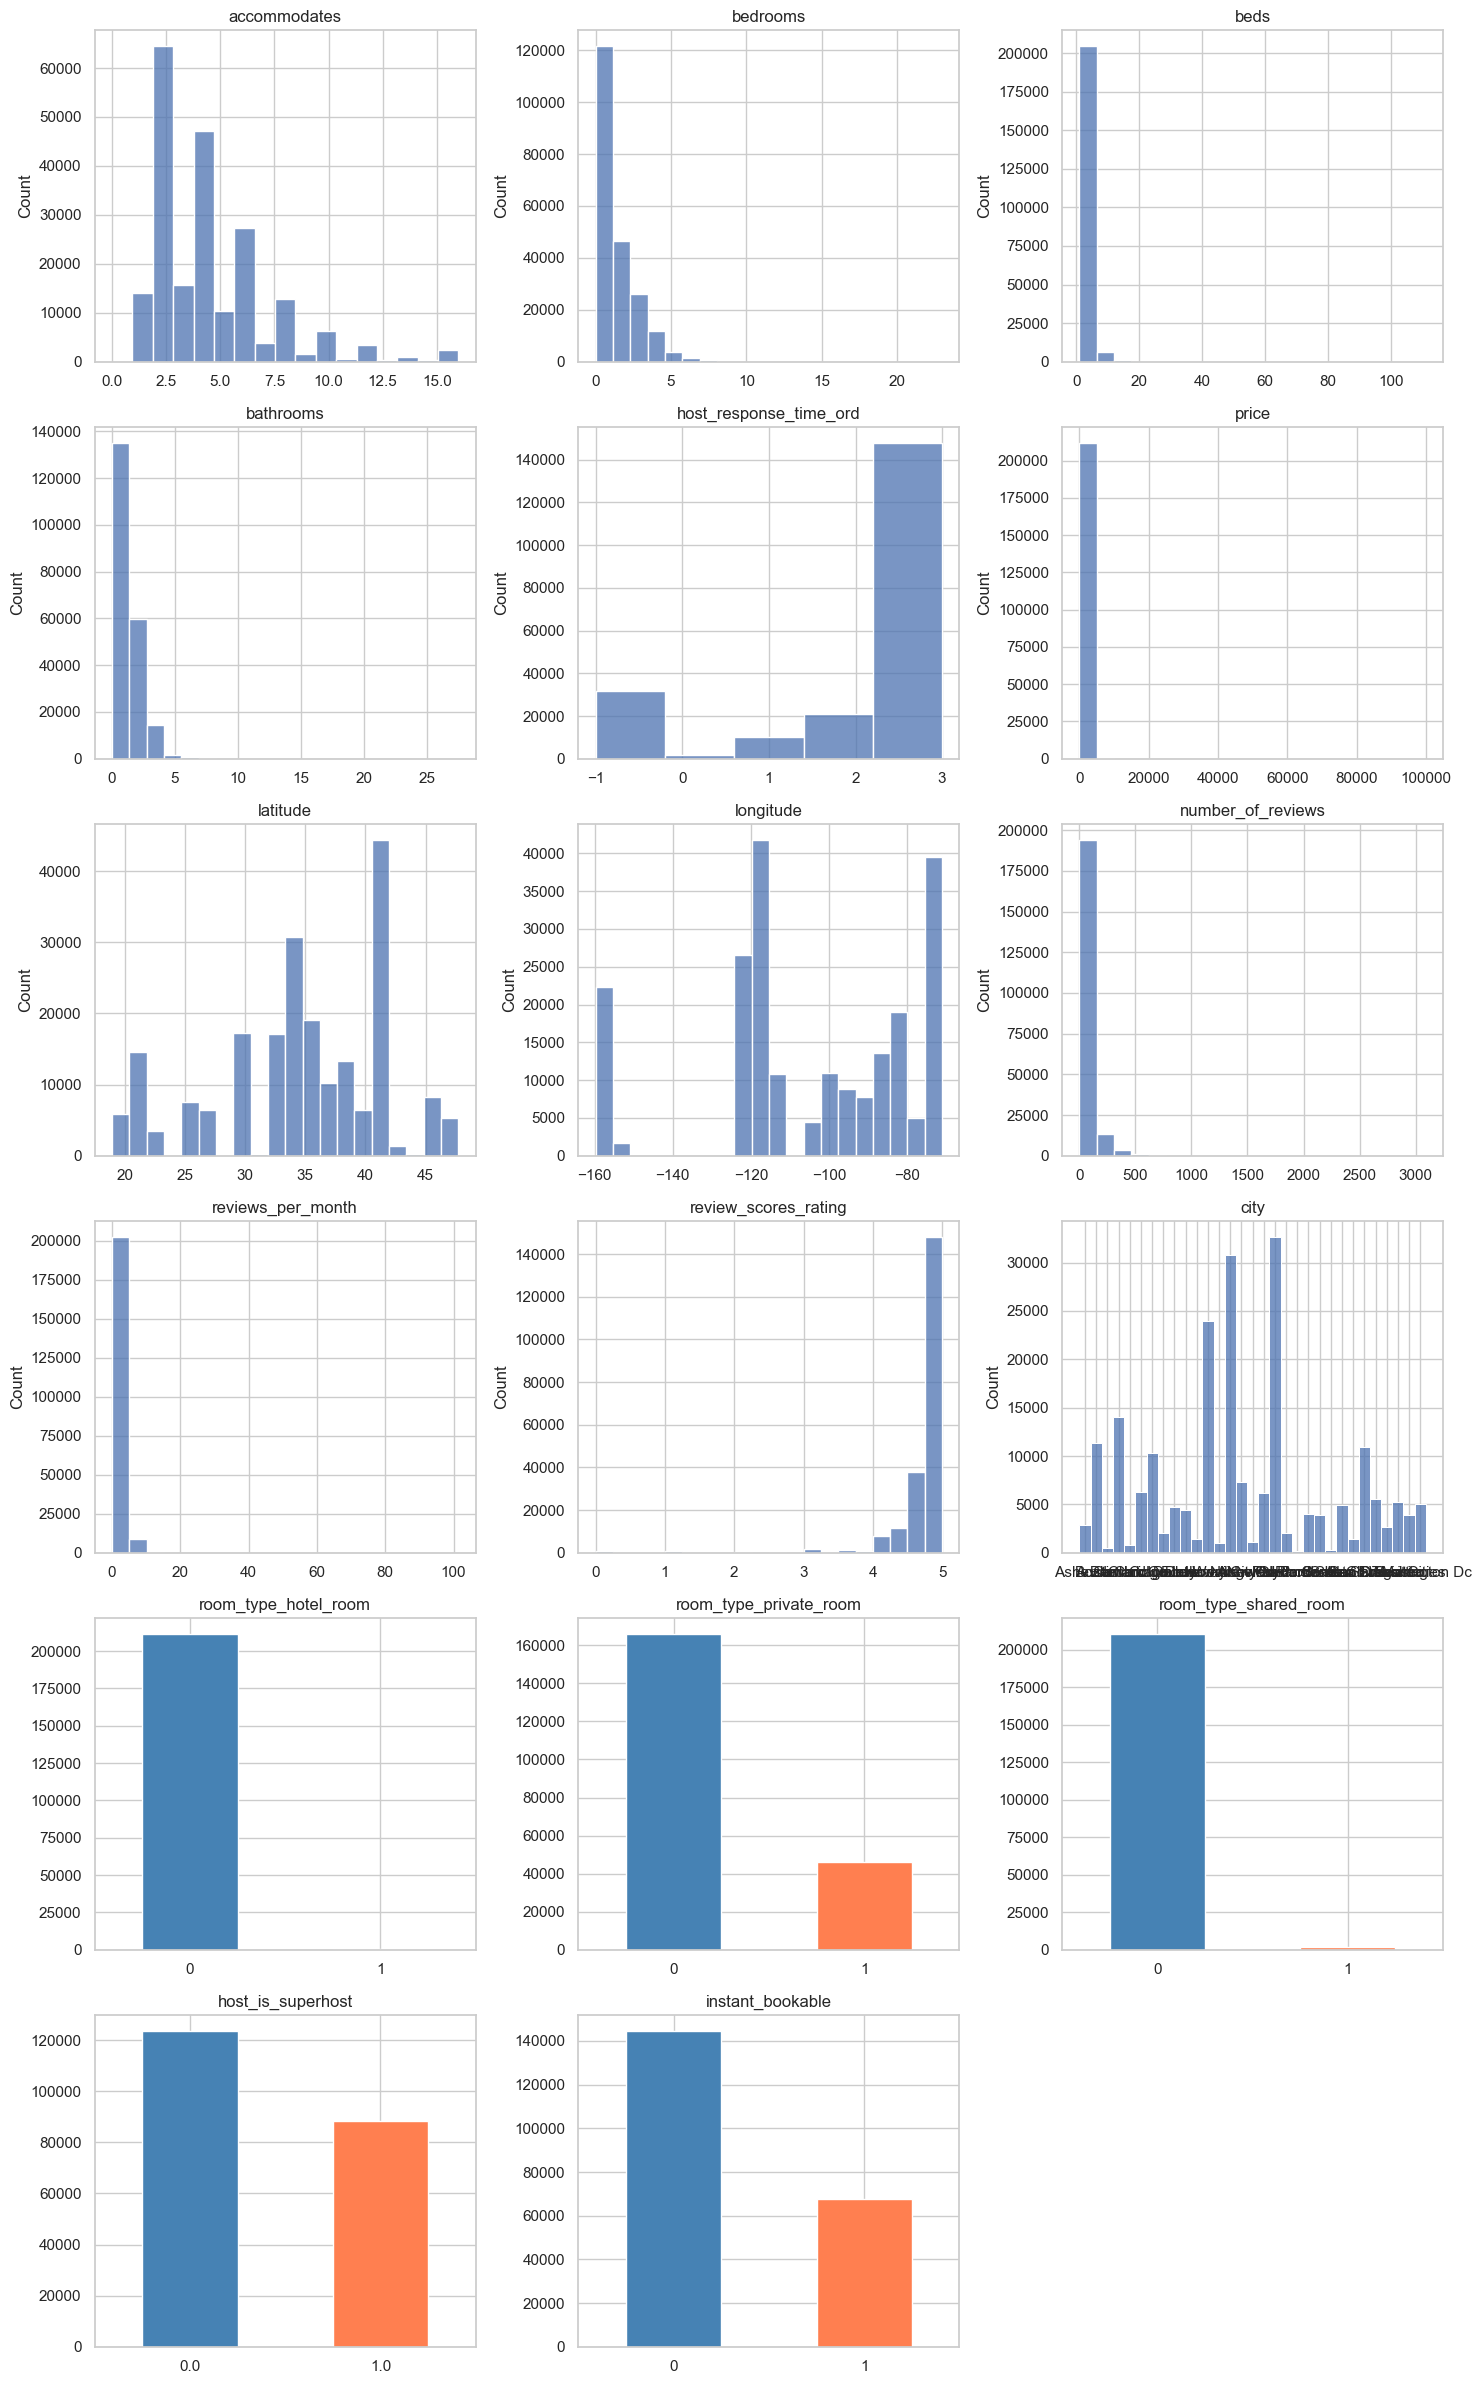

In [7]:
n_cols = 3
n_rows = math.ceil(len(plot_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    if col in binary_cols:
        df[col].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    else:
        bins = min(df[col].nunique(), 20)
        sns.histplot(df[col], kde=False, bins=bins, ax=ax)
    
    ax.set_title(col)
    ax.set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [8]:
np.log(df.price)

C:\Users\cococ\miniconda3\envs\ds\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


0         4.605170
1         4.605170
2         4.189655
3         3.806662
4         4.605170
            ...   
212022    5.855072
212023    4.499810
212024    4.219508
212025    4.382027
212026    4.634729
Name: price, Length: 212027, dtype: float64

### Analysis
* Most variables are heavily right-skewed, with the majority of listings concentrated at lower values and a small number of extreme outliers. This is clearly shown in price, number of reviews, and beds.
* Will do log scaling before modeling
* Will review outliers

In [9]:
# make copies of columns to perform log on 

df['price_log'] = np.log1p(df['price'])
df['number_of_reviews_log'] = np.log1p(df['number_of_reviews'])
df['beds_log'] = np.log1p(df['beds'])
df['accommodates_log'] = np.log1p(df['accommodates'])
df['bedrooms_log'] = np.log1p(df['bedrooms'])
df['bathrooms_log'] = np.log1p(df['bathrooms'])

In [10]:
# columns to transform
skewed_cols = [
    'price',
    'number_of_reviews',
    'beds',
    'accommodates',
    'bedrooms',
    'bathrooms']

In [11]:
# log transformed
for col in skewed_cols:
    df[f'{col}_log'] = np.log1p(df[col])

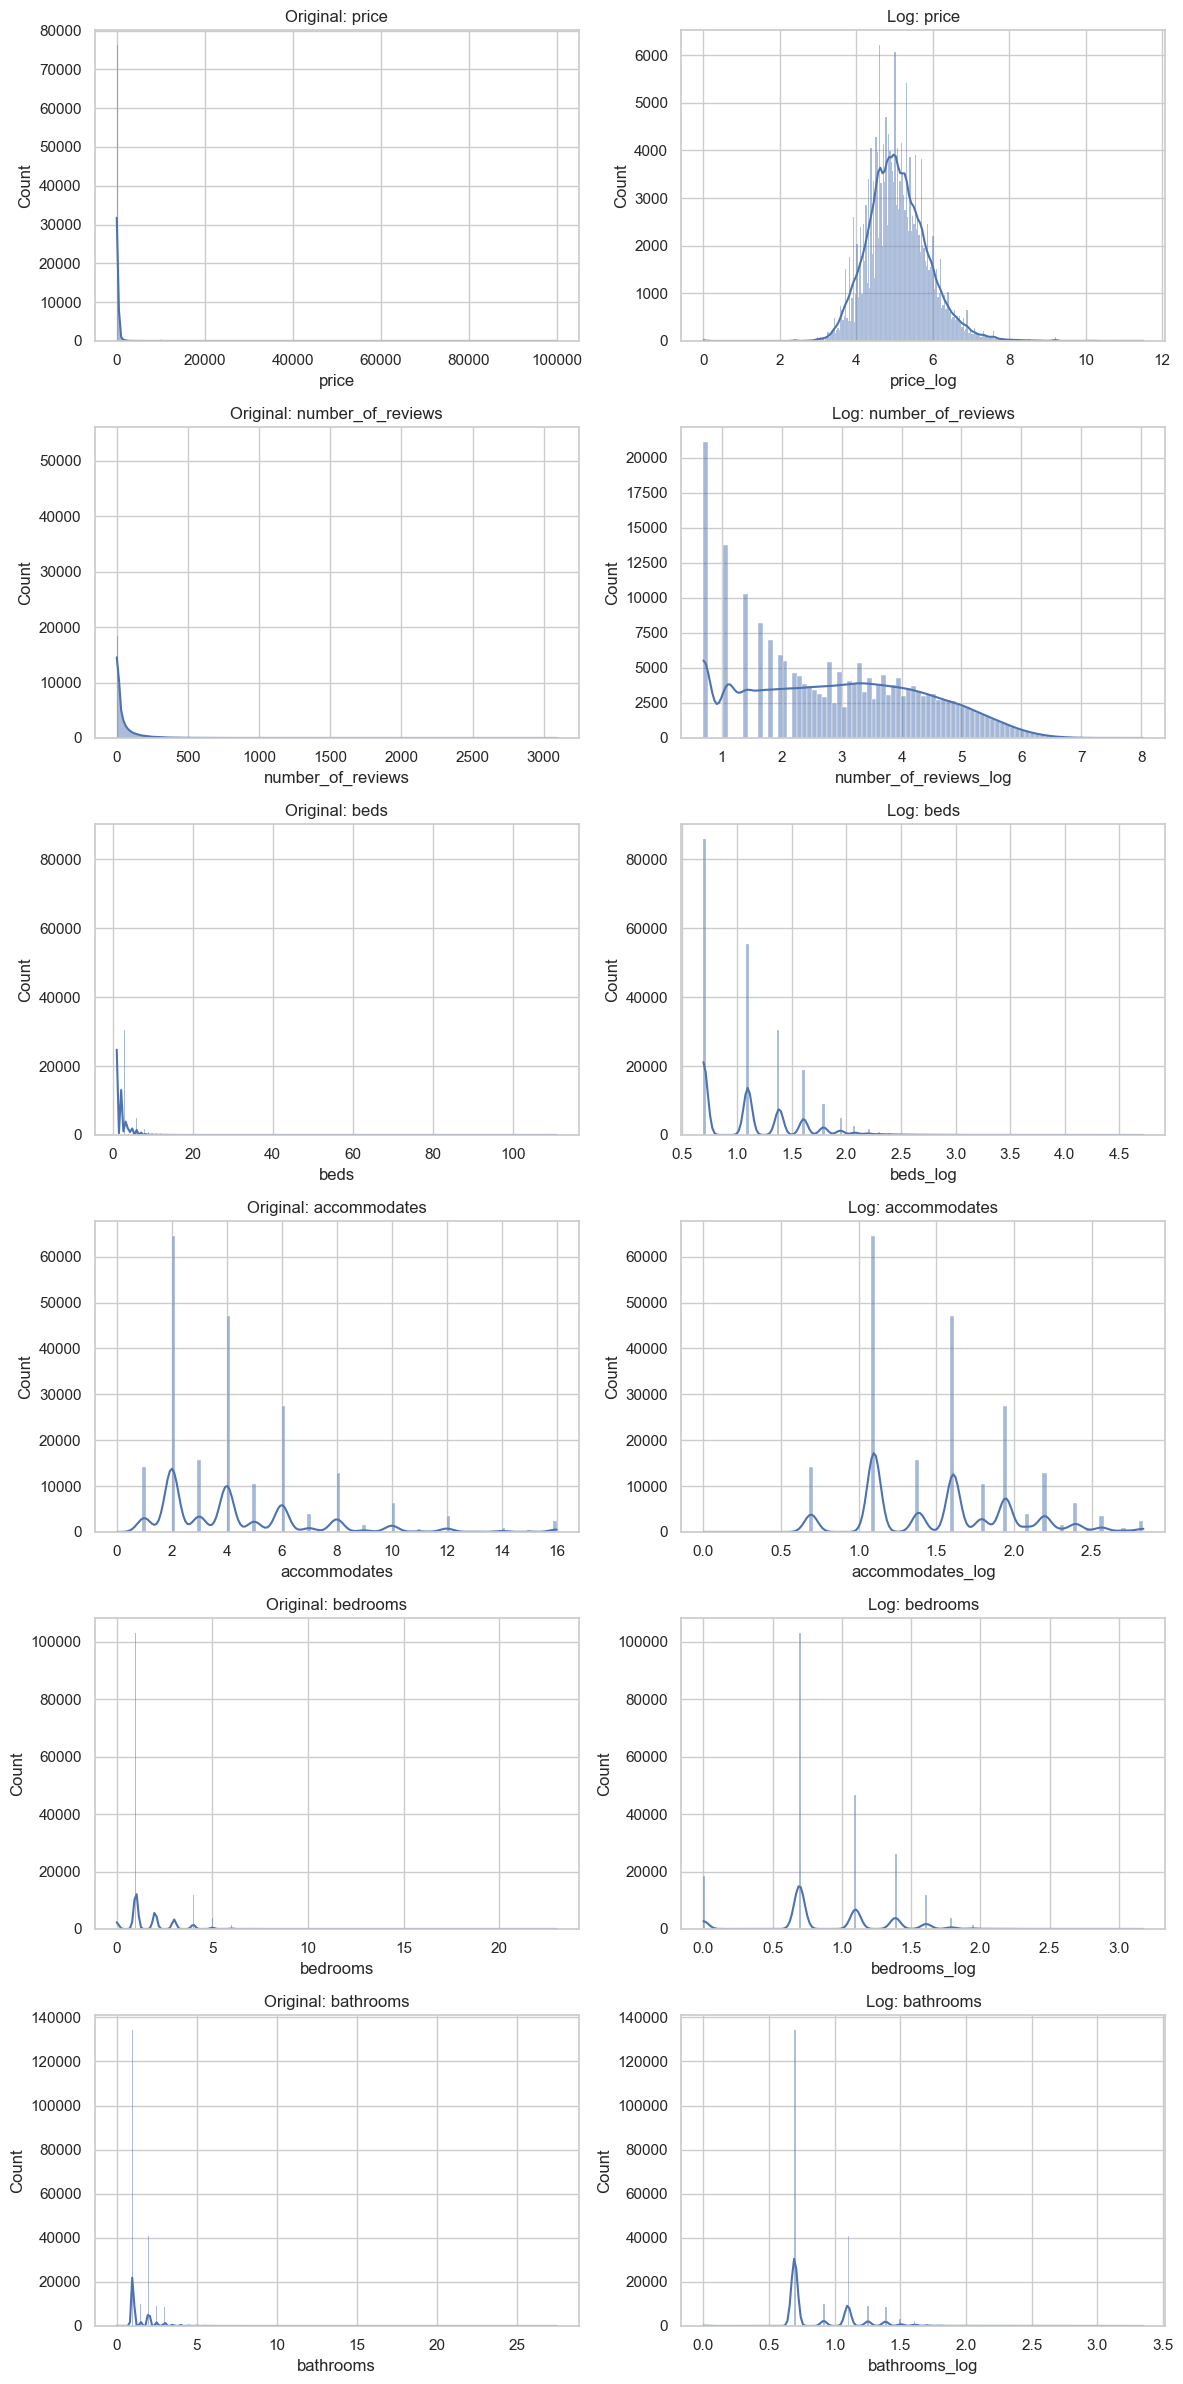

In [12]:
# compare before/after

fig, axes = plt.subplots(len(skewed_cols), 2, figsize=(12, 4 * len(skewed_cols)))

for i, col in enumerate(skewed_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Original: {col}')
    
    sns.histplot(df[f'{col}_log'], kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f'Log: {col}')

plt.tight_layout()
plt.show()

In [13]:
df['price_log'] = np.log1p(df['price'])
df['number_of_reviews_log'] = np.log1p(df['number_of_reviews'])

### Analysis: 
Price and number of reviews were right skewed with long tails. I applied log transformation to reduce skewn, compress outliers, and make it better for modeling. Other numeric features (beds, bedrooms, bathrooms, accommodates) were evaluated but I decided on keeping the original data since the transformation didn't signficantly change the results and the numbers are discrete and limited.

### Investigate Outliers

Before looking into feature relationships, I looked at outliers that we identified in the previous step.
Since they can influence correlation coefficients and regression models, I wanted to see if they're legit observations or errors/quality issues.

### Goals
- Identify extreme values in key continuous variables
- Determine if outliers are real listings or data errors
- Decide whether keep, remove, transform.

### Variables to Review
- Price
- Beds
- Bedrooms
- Bathrooms
- Number of Reviews
  
### Methods
1. Review boxplots for each suspect variable
2. Calculate IQR bounds / percentile cutoffs
3. Inspect top extreme observations directly
4. Make case-by-case decisions on treatment

### Questions to Consider
- Is the value feasible in the real world?
- Could this represent a luxury/large-group listing rather than bad data?
- Is the value most likely a typo, scrape issue, or malformed entry?
- Would keeping this point distort downstream analysis disproportionately?

### Deliverables
- Summary of identified outliers
- Rationale for retaining/removing/capping
- Cleaned dataframe prepared for correlation analysis

In [14]:
outlier_cols = [
    'price',
    'beds',
    'bedrooms',
    'bathrooms',
    'number_of_reviews']

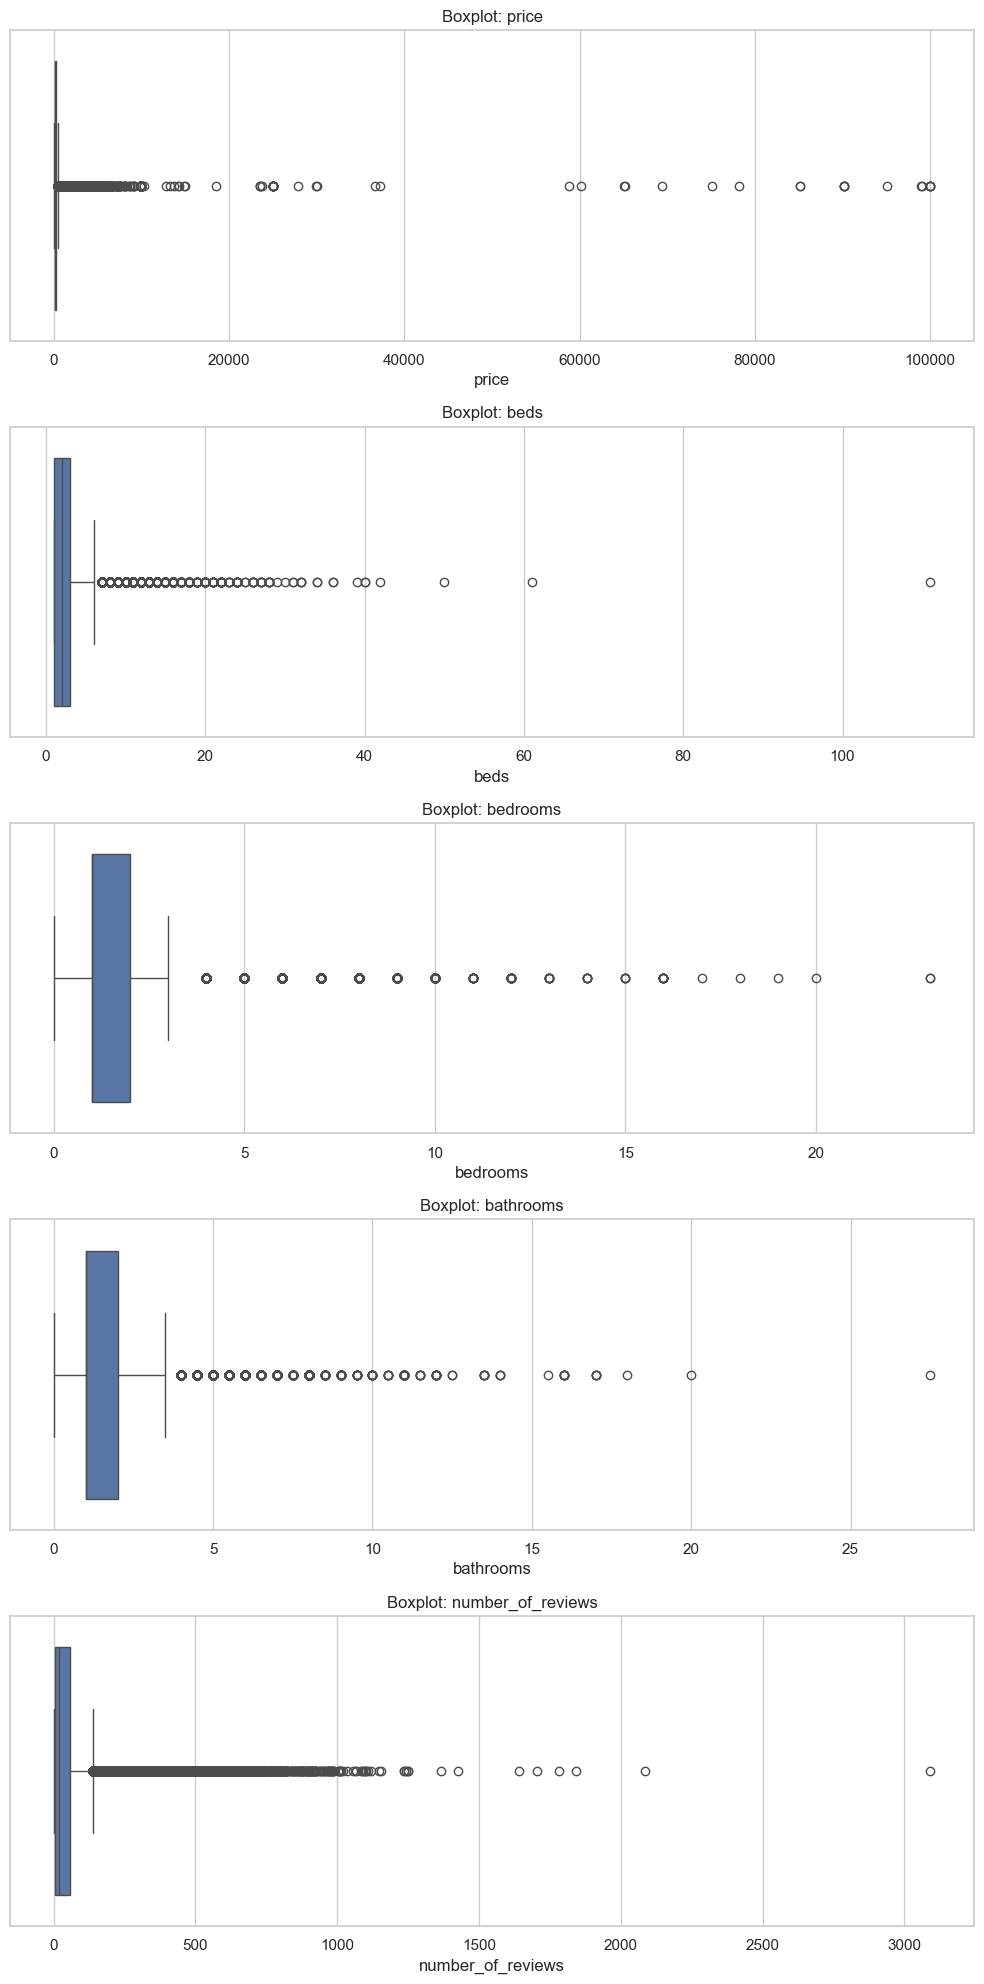

In [15]:
fig, axes = plt.subplots(len(outlier_cols), 1, figsize=(10, 4 * len(outlier_cols)))

for i, col in enumerate(outlier_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

In [16]:
outlier_summary = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    
    outlier_summary.append({
        'column': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'n_outliers': n_outliers,
        'pct_outliers': round(n_outliers / len(df) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,column,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
0,price,95.0,257.0,162.0,-148.0,500.0,15801,7.45
1,beds,1.0,3.0,2.0,-2.0,6.0,7516,3.54
2,bedrooms,1.0,2.0,1.0,-0.5,3.5,17740,8.37
3,bathrooms,1.0,2.0,1.0,-0.5,3.5,5204,2.45
4,number_of_reviews,4.0,58.0,54.0,-77.0,139.0,21316,10.05


In [17]:
for col in outlier_cols:
    print(f'\n{col}')
    print(df[col].quantile([0.90, 0.95, 0.99, 0.995, 1.00]))


price
0.900       436.00
0.950       625.00
0.990      1454.74
0.995      2000.00
1.000    100000.00
Name: price, dtype: float64

beds
0.900      5.0
0.950      6.0
0.990      9.0
0.995     11.0
1.000    111.0
Name: beds, dtype: float64

bedrooms
0.900     3.0
0.950     4.0
0.990     6.0
0.995     6.0
1.000    23.0
Name: bedrooms, dtype: float64

bathrooms
0.900     2.5
0.950     3.0
0.990     4.5
0.995     5.5
1.000    27.5
Name: bathrooms, dtype: float64

number_of_reviews
0.900     140.0
0.950     214.0
0.990     410.0
0.995     500.0
1.000    3091.0
Name: number_of_reviews, dtype: float64


In [18]:
# look at outliers
for col in outlier_cols:
    threshold = df[col].quantile(0.995)

    cols_to_show = list(dict.fromkeys([
        col, 'id', 'price', 'beds', 'bedrooms', 'bathrooms', 'accommodates'
    ]))

    print(f'\nTop 10 rows above 99.5th percentile for {col}:')

    display(
        df[df[col] > threshold][cols_to_show]
        .sort_values(by=col, ascending=False)
        .head(10)
    )


Top 10 rows above 99.5th percentile for price:


,price,id,beds,bedrooms,bathrooms,accommodates
184336,100000.0,47475849,1.0,1.0,1.0,2
19083,100000.0,53810192,2.0,2.0,2.0,6
83274,99999.0,53775685,1.0,1.0,1.0,2
30835,99998.0,24894665,4.0,3.0,1.0,6
81121,99110.0,34781289,2.0,1.0,1.0,2
146655,99000.0,683438366892259448,1.0,0.0,0.5,16
170954,95117.0,579025067192833214,2.0,2.0,1.0,4
40632,90180.0,52201755,1.0,1.0,1.0,2
58276,90153.0,665140637804733985,2.0,3.0,1.0,6
110429,90150.0,546483898096607267,2.0,1.0,1.0,2



Top 10 rows above 99.5th percentile for beds:


,beds,id,price,bedrooms,bathrooms,accommodates
117903,111.0,48120470,120.0,1.0,1.0,3
6415,61.0,28466259,4401.0,23.0,17.0,16
169223,50.0,33392877,1600.0,6.0,3.0,12
156082,42.0,2261367,2029.0,14.0,15.5,16
116919,40.0,37291927,1571.0,12.0,12.0,16
118056,40.0,48075554,424.0,16.0,12.5,16
6414,39.0,28463789,2398.0,15.0,10.5,16
4766,36.0,15665823,1246.0,6.0,6.5,16
119261,36.0,54073294,1249.0,16.0,16.0,16
181000,34.0,21502368,2343.0,12.0,9.0,16



Top 10 rows above 99.5th percentile for bedrooms:


,bedrooms,id,price,beds,bathrooms,accommodates
6415,23.0,28466259,4401.0,61.0,17.0,16
93739,23.0,549518543728558414,136.0,1.0,1.0,2
189375,20.0,822731549014682607,275.0,1.0,20.0,2
162089,19.0,11092632,3714.0,20.0,9.0,16
127254,18.0,46898556,3464.0,21.0,18.0,16
127163,17.0,51500727,362.0,6.0,3.5,10
118056,16.0,48075554,424.0,40.0,12.5,16
119261,16.0,54073294,1249.0,36.0,16.0,16
119978,16.0,619399716521823613,1300.0,16.0,12.0,16
203921,16.0,25371311,37.0,1.0,3.5,4



Top 10 rows above 99.5th percentile for bathrooms:


,bathrooms,id,price,beds,bedrooms,accommodates
180614,27.5,18415873,179.0,2.0,2.0,6
189375,20.0,822731549014682607,275.0,1.0,20.0,2
127254,18.0,46898556,3464.0,21.0,18.0,16
53496,17.0,22727793,53.0,1.0,1.0,16
53497,17.0,22747038,82.0,1.0,1.0,1
116955,17.0,38095416,4900.0,22.0,15.0,16
6415,17.0,28466259,4401.0,61.0,23.0,16
119131,16.0,53670065,1642.0,28.0,16.0,16
118554,16.0,50246654,1299.0,28.0,16.0,16
200401,16.0,46993410,173.0,2.0,0.0,1



Top 10 rows above 99.5th percentile for number_of_reviews:


,number_of_reviews,id,price,beds,bedrooms,bathrooms,accommodates
31235,3091,29819757,173.0,1.0,1.0,1.0,2
93111,2084,42409434,116.0,1.0,1.0,1.0,2
134537,1842,44799007,234.0,1.0,0.0,1.0,2
177111,1784,8357,164.0,2.0,1.0,1.0,3
38074,1705,35158303,226.0,1.0,0.0,1.0,3
143869,1642,37122502,155.0,1.0,1.0,1.0,2
119380,1425,54227245,117.0,2.0,1.0,1.0,4
52865,1367,1733052,101.0,5.0,1.0,1.0,4
198019,1251,3861673,73.0,1.0,1.0,1.0,2
114430,1251,329997,104.0,1.0,1.0,1.0,2


## Outlier Review

Outlier price listings manually reviewed to determine if they were luxury listings or anomalies. 

Findings:
* Confirmed several high-priced listings were legitimate, leave as is.
* Confirmed multiple high-priced listings were inactive/off-market listings, unusually restrictive minimum-night requirements, or pricing inconsistent with listing characteristics. Remove from dataset.
* High bed/bath count associated with entire hotel buy outs, multiple units, corporate stays, and similar offerings. The market segment may skew the majority of data, so I am going to remove those outliers from the dataset.

In [19]:
# explore the values and percentiles to see where a good cut off might be for extreme outliers
size_cols = ['price','bedrooms', 'beds', 'bathrooms']

for col in size_cols:
    print(f"\n{col}")
    print(df[col].describe(percentiles=[.90, .98, .998]))


price
count    212027.000000
mean        244.901116
std         956.491901
min           0.000000
90%         436.000000
98%         999.000000
99.8%      3600.000000
max      100000.000000
Name: price, dtype: float64

bedrooms
count    212027.000000
mean          1.678253
std           1.231207
min           0.000000
90%           3.000000
98%           5.000000
99.8%         8.000000
max          23.000000
Name: bedrooms, dtype: float64

beds
count    212027.000000
mean          2.389196
std           1.921364
min           1.000000
90%           5.000000
98%           8.000000
99.8%        14.000000
max         111.000000
Name: beds, dtype: float64

bathrooms
count    212027.000000
mean          1.494314
std           0.867709
min           0.000000
90%           2.500000
98%           4.000000
99.8%         7.000000
max          27.500000
Name: bathrooms, dtype: float64


remove_ids = []

In [20]:
price_mask = (
    (df['price'] > 90000))
price_cutoff = df['price'].quantile(0.995)   # or 0.99

df[price_mask][['id','price']].sort_values('price', ascending=False)

,id,price
19083,53810192,100000.0
184336,47475849,100000.0
83274,53775685,99999.0
30835,24894665,99998.0
81121,34781289,99110.0
146655,683438366892259448,99000.0
170954,579025067192833214,95117.0
40632,52201755,90180.0
58276,665140637804733985,90153.0
110429,546483898096607267,90150.0


In [21]:
# create masks
commercial_mask = (
    (df['bedrooms'] > 12) |
    (df['beds'] > 14) |
    (df['bathrooms'] > 8)
)

price_cutoff = df['price'].quantile(0.995)
price_mask = df['price'] > price_cutoff

combined_mask = price_mask | commercial_mask

# build exclusion reason before splitting (np.where handles overlaps - commercial takes priority)
exclusion_reason = np.where(
    commercial_mask, 'commercial',
    np.where(price_mask, 'price_outlier', None)
)

# save removed rows with reason attached
removed_listings = df[combined_mask].copy()
removed_listings['exclude_reason'] = exclusion_reason[combined_mask]

# cleaned dataframe
df_clean = df[~combined_mask].copy()

# quick checks
print("Price cutoff:", price_cutoff)
print("Price outliers removed:", price_mask.sum())
print("Structural outliers removed:", commercial_mask.sum())
print("Total removed:", combined_mask.sum())
print("Cleaned shape:", df_clean.shape)

removed_listings[['id', 'price', 'bedrooms', 'beds', 'bathrooms']].sort_values(
    'price', ascending=False).head(10)

Price cutoff: 2000.0
Price outliers removed: 1016
Structural outliers removed: 547
Total removed: 1480
Cleaned shape: (210547, 81)


,id,price,bedrooms,beds,bathrooms
19083,53810192,100000.0,2.0,2.0,2.0
184336,47475849,100000.0,1.0,1.0,1.0
83274,53775685,99999.0,1.0,1.0,1.0
30835,24894665,99998.0,3.0,4.0,1.0
81121,34781289,99110.0,1.0,2.0,1.0
146655,683438366892259448,99000.0,0.0,1.0,0.5
170954,579025067192833214,95117.0,2.0,2.0,1.0
40632,52201755,90180.0,1.0,1.0,1.0
58276,665140637804733985,90153.0,3.0,2.0,1.0
110429,546483898096607267,90150.0,1.0,2.0,1.0


In [22]:
(removed_listings
    .groupby('exclude_reason')[['price', 'bedrooms', 'beds', 'bathrooms']]
    .agg(['median', 'count']))

price       bedrooms         beds       bathrooms      
                median count   median count median count    median count
exclude_reason                                                          
commercial       770.0   547      7.0   547   16.0   547       6.0   547
price_outlier   3150.0   933      4.0   933    4.0   933       3.0   933

In [23]:
df_clean.shape

(210547, 81)

<Axes: xlabel='price', ylabel='Count'>

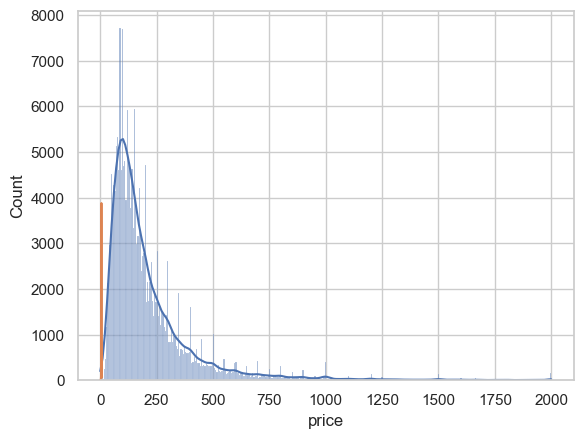

In [24]:
sns.histplot(df_clean['price'], kde=True)
sns.histplot(np.log1p(df_clean['price']), kde=True)

<Axes: >

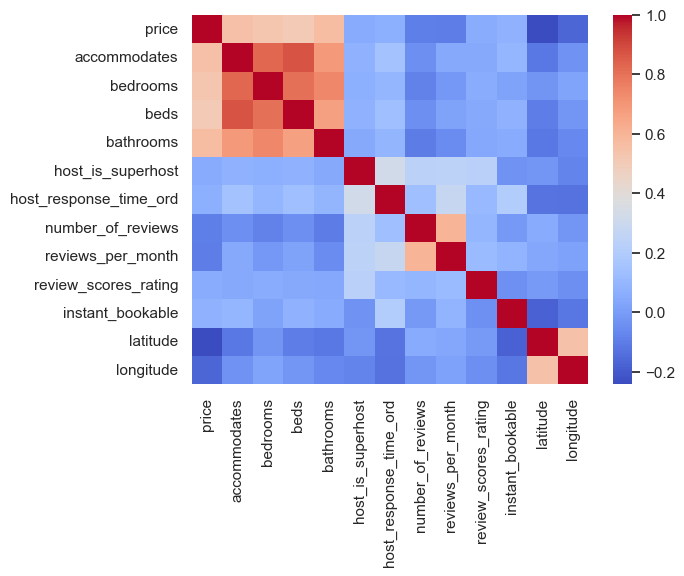

In [25]:
core_cols = [
    'price',
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'host_is_superhost',
    'host_response_time_ord',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'instant_bookable',
    'latitude',
    'longitude'
]

corr = df_clean[core_cols].corr()

sns.heatmap(corr, cmap='coolwarm')

In [26]:
corr['price'].sort_values(ascending=False)

price                     1.000000
bathrooms                 0.564996
accommodates              0.550764
bedrooms                  0.527479
beds                      0.507752
instant_bookable          0.080847
host_response_time_ord    0.063211
review_scores_rating      0.057873
host_is_superhost         0.050299
number_of_reviews        -0.096154
reviews_per_month        -0.099812
longitude                -0.168192
latitude                 -0.242690
Name: price, dtype: float64

### Create a set to house inactive listings
Since I'm filtering listings in a few different ways, I will most likely keep adding inactive listings as I go through them manually. 

In [27]:
inactive_ids = set()

### Review
I realized that encoding room type and removing 'entire home' made it harder for visualization, so I'm adding back the categorical columns to visually inspect the relationship

In [28]:
# add back columns for room types for easier visualization
df_clean['room_type'] = 'Entire home/apt'

df_clean.loc[df_clean['room_type_private_room'] == 1, 'room_type'] = 'Private room'
df_clean.loc[df_clean['room_type_shared_room'] == 1, 'room_type'] = 'Shared room'
df_clean.loc[df_clean['room_type_hotel_room'] == 1, 'room_type'] = 'Hotel room'

([0, 1, 2, 3],
 [Text(0, 0, 'Entire home/apt'),
  Text(1, 0, 'Private room'),
  Text(2, 0, 'Shared room'),
  Text(3, 0, 'Hotel room')])

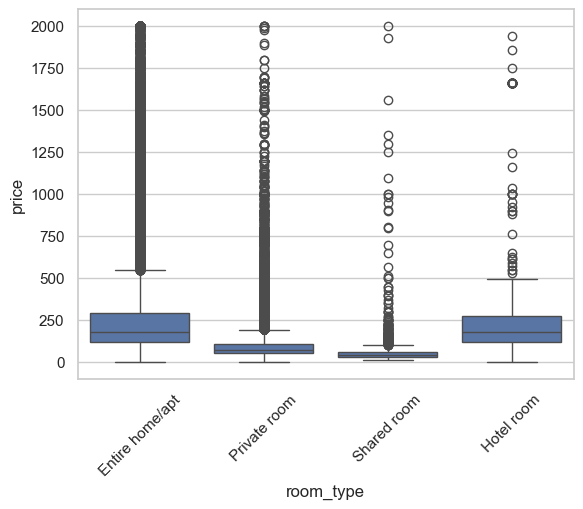

In [29]:
sns.boxplot(data=df_clean, x='room_type', y='price')
plt.xticks(rotation=45)

In [30]:
# filter shared rooms with high prices to manually check them. Use for loop to create link for faster manual checking, then mass open with chrome extension.

ids = df_clean.loc[
    (df_clean['room_type_shared_room'] == 1) & 
    (df_clean['price'] > 300), 
    'id'
]

for id in ids:
    print(f"https://www.airbnb.com/rooms/{id}")

https://www.airbnb.com/rooms/8554989
https://www.airbnb.com/rooms/9500935
https://www.airbnb.com/rooms/14521992
https://www.airbnb.com/rooms/22245485
https://www.airbnb.com/rooms/557326590644593073
https://www.airbnb.com/rooms/558935297587570328
https://www.airbnb.com/rooms/7275060
https://www.airbnb.com/rooms/39225953
https://www.airbnb.com/rooms/25302082
https://www.airbnb.com/rooms/716743726332299007
https://www.airbnb.com/rooms/25456431
https://www.airbnb.com/rooms/54117350
https://www.airbnb.com/rooms/603038129482973267
https://www.airbnb.com/rooms/28048168
https://www.airbnb.com/rooms/9629756
https://www.airbnb.com/rooms/11628861
https://www.airbnb.com/rooms/618229969802912830
https://www.airbnb.com/rooms/1951714
https://www.airbnb.com/rooms/6937897
https://www.airbnb.com/rooms/23169146
https://www.airbnb.com/rooms/32501807
https://www.airbnb.com/rooms/52519640
https://www.airbnb.com/rooms/619144
https://www.airbnb.com/rooms/728481699229802607
https://www.airbnb.com/rooms/3796130

In [31]:
# listings marked as shared, but are actually entire homes
entire_home_ids = [22389574, 25456431]

# add inactive listings from room shares > 300
inactive_ids.update([
    9500935, 557326590644593073, 668876766672896434, 804353806863519204,
    41497802, 781881685799321121, 676271905304449028, 7275060, 39225953,
    46031992, 716743726332299007, 21299151, 69015, 33716548, 6576882,
    44398225, 39223518, 38817832, 12760823, 54117350, 603038129482973267,
    780582170025187261, 5046140, 753731123816065920, 9629756, 11628861,
    618229969802912830, 676304446219075286, 39549128, 734760353530493041,
    734751927150020653, 6937897, 628333280492085480, 32501807, 52519640,
    619144, 31439428, 32089161, 728481699229802607, 778327608834280560,
    37961305, 769636927103230399, 33396290, 38215806, 7310835, 774899,
    850935770617944118, 10929290, 48398910, 16726215, 42036525, 29826153,
    16401431, 22860173, 22972672,
])


# fix mislabeled listings on original df
df.loc[df['id'].isin(entire_home_ids), 'room_type_shared_room'] = 0

# rebuild df_clean from original df
df_clean = df[
    ~combined_mask &
    ~df['id'].isin(inactive_ids)
].copy()

print(f"Inactive remaining: {df_clean['id'].isin(inactive_ids).sum()}")  # should be 0
print(f"Clean shape: {df_clean.shape}")


Inactive remaining: 0
Clean shape: (210525, 81)


In [32]:
# manually inspect private rooms that are over 2500 nightly

ids = df_clean.loc[
    (df_clean['room_type_private_room'] == 1) & 
    (df_clean['price'] > 2500), 
    'id'
]

for id in ids:
    print(f"https://www.airbnb.com/rooms/{id}")

In [33]:
# inactive private rooms > 2500
inactive_ids.update([
    235873572, 797148744366215609, 849194920814650859, 42388908, 42312478,
    609692138842591563, 704255194541847240, 765963932387225699, 828440127039471744,
    46707446, 42543983, 772527262639208924, 772530630468886320, 772514695053488857,
    772523252167073236, 772523054615413105, 715788596004309948, 715789169240748205,
    715789838753660311, 46597956, 32476606])

### Outliers Review
<b>Price:</b> some listings were entire buyouts of hotels, bnbs, houses, multiplexs, etc. After manually inspecting, I chose to remove those listings above 99.8% range because I felt they would alter the data too much (some being priced at 100,000)

<b>High bed/bath count:</b> some listings were entire buyouts, once again, I removed the 99.8% - marking them as commercial properties

<b>Shared rooms/high price:</b> left most as is, removed inactive listings

<b>Private rooms/high price:</b> most were hotel rooms/suites, left as is. Removed inactive listings.

<b>Entire rooms/high price:</b> did not look into since there's a wide range of prices and high volume.

([0, 1, 2, 3],
 [Text(0, 0, 'Entire home/apt'),
  Text(1, 0, 'Private room'),
  Text(2, 0, 'Shared room'),
  Text(3, 0, 'Hotel room')])

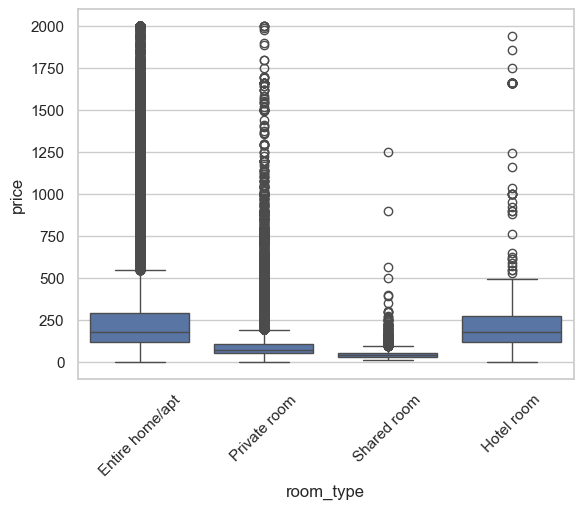

In [34]:
# add back columns for room types for easier visualization
df_clean['room_type'] = 'Entire home/apt'

df_clean.loc[df_clean['room_type_private_room'] == 1, 'room_type'] = 'Private room'
df_clean.loc[df_clean['room_type_shared_room'] == 1, 'room_type'] = 'Shared room'
df_clean.loc[df_clean['room_type_hotel_room'] == 1, 'room_type'] = 'Hotel room'

sns.boxplot(data=df_clean, x='room_type', y='price')
plt.xticks(rotation=45)

In [35]:
ids = df_clean.loc[
    (df_clean['room_type_private_room'] == 1) & 
    (df_clean['price'] > 2500),
    'id'
]

for id in ids:
    print(f"https://www.airbnb.com/rooms/{id}")

### Review correlation

<Axes: >

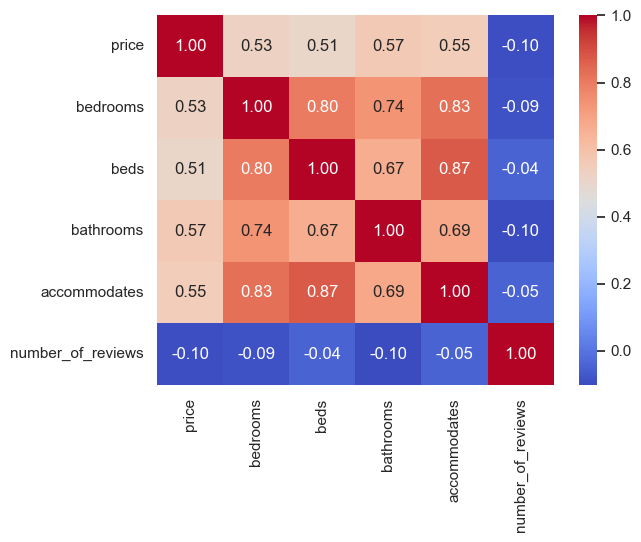

In [36]:
corr_cols = ['price', 'bedrooms', 'beds', 'bathrooms', 'accommodates', 'number_of_reviews']
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')

In [37]:
df_clean.groupby('room_type')['price'].agg(['median', 'mean', 'count'])

,median,mean,count
room_type,,,
Entire home/apt,179.0,247.473188,162221
Hotel room,179.0,281.580737,706
Private room,74.0,104.405789,45982
Shared room,40.0,54.161510,1616


Text(0.5, 1.0, 'Price by Location')

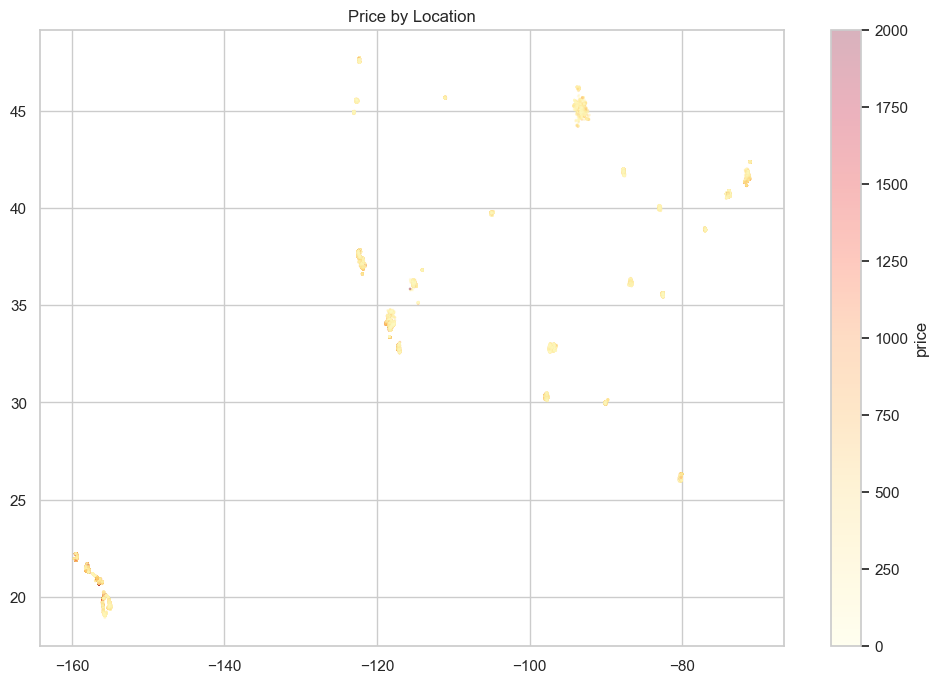

In [38]:
plt.figure(figsize=(12, 8))
plt.scatter(df_clean['longitude'], df_clean['latitude'], 
            c=df_clean['price'], cmap='YlOrRd', alpha=0.3, s=1)
plt.colorbar(label='price')
plt.title('Price by Location')

In [39]:
 # look specifically at amenities
amenity_cols = [col for col in df_clean.columns if col.startswith('amenity_')] 
amenity_corr = df_clean[amenity_cols].corrwith(df_clean['price']).sort_values(ascending=False)
amenity_corr.head(20)  # top 20 price driver amenities

amenity_dishwasher        0.257643
amenity_pool              0.239615
amenity_hot_tub           0.238548
amenity_bbq_grill         0.237785
amenity_beach_access      0.188281
amenity_washer            0.187405
amenity_dryer             0.181784
amenity_patio_balcony     0.174328
amenity_fireplace         0.154599
amenity_oven              0.153727
amenity_tv                0.153585
amenity_view_water        0.153255
amenity_kids_amenities    0.142343
amenity_stove             0.130005
amenity_kitchen           0.117242
amenity_coffee_maker      0.115213
amenity_blender           0.110230
amenity_bathtub           0.107530
amenity_gym               0.106963
amenity_sound_system      0.105729
dtype: float64

In [40]:
df_clean.groupby('room_type')['number_of_reviews'].agg(['median', 'mean', 'count']).round(2)

,median,mean,count
room_type,,,
Entire home/apt,19.0,52.16,162221
Hotel room,24.0,73.95,706
Private room,13.0,45.40,45982
Shared room,10.0,31.86,1616


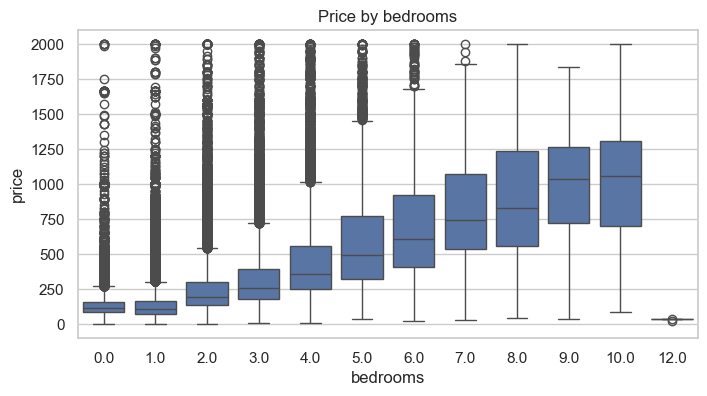

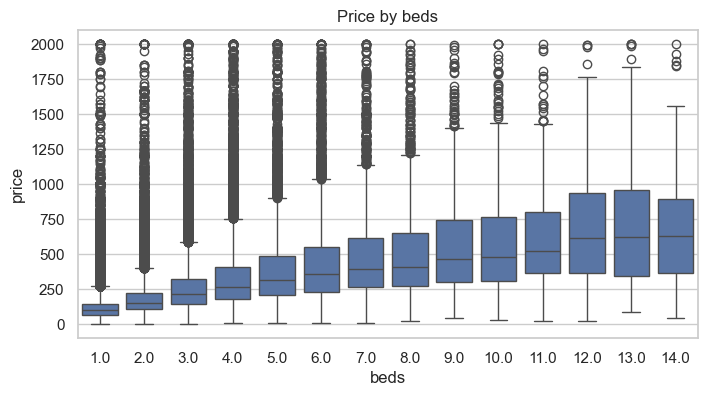

In [41]:
structural_cols = ['bedrooms', 'beds']

for col in structural_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df_clean, x=col, y='price')
    plt.title(f'Price by {col}')
    plt.show()

### Location Analysis

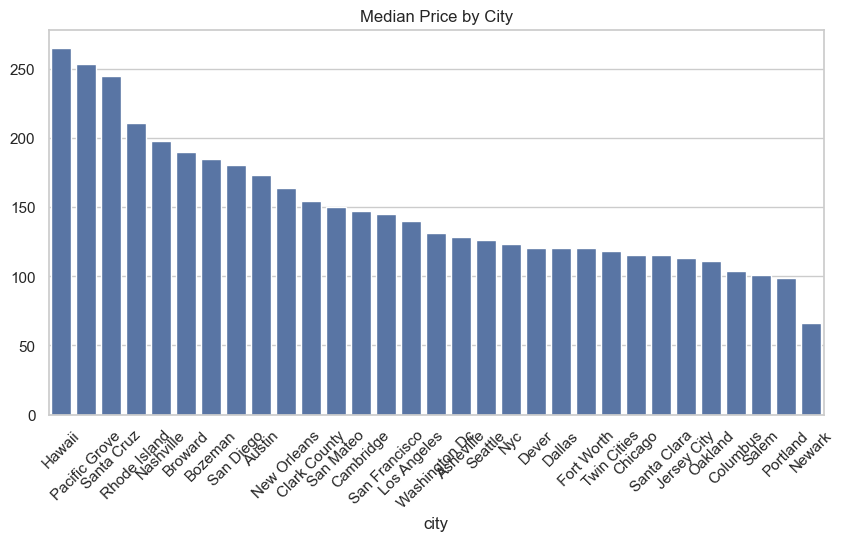

In [42]:
city_price = (
    df_clean.groupby('city')['price']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(x=city_price.index, y=city_price.values)
plt.xticks(rotation=45)
plt.title('Median Price by City')
plt.show()

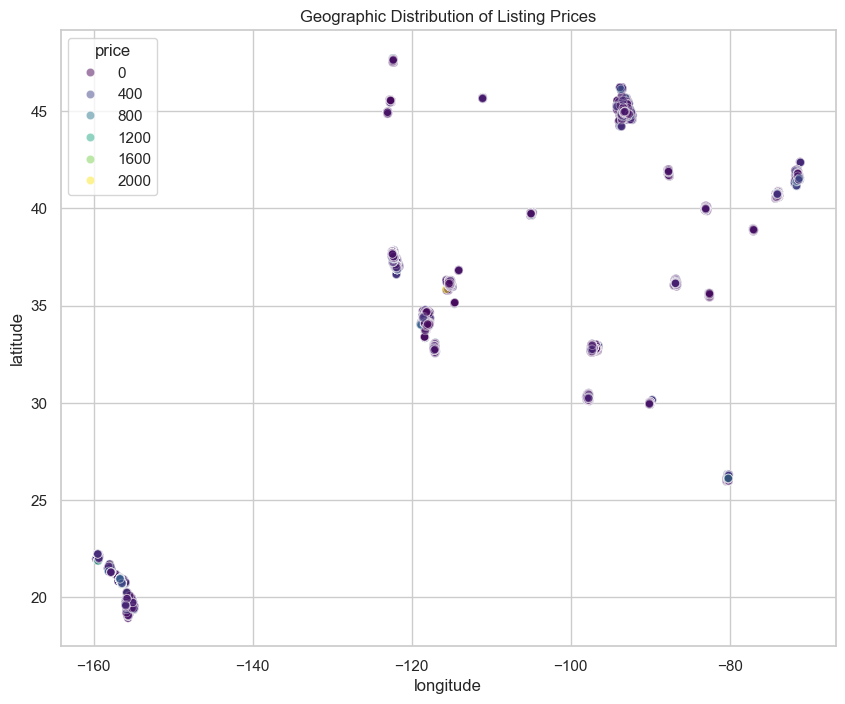

In [43]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=df_clean,
    x='longitude',
    y='latitude',
    hue='price',
    palette='viridis',
    alpha=0.5
)
plt.title('Geographic Distribution of Listing Prices')
plt.show()

In [44]:
city_summary = df_clean.groupby('city').agg({
    'price':'median',
    'reviews_per_month':'median'
}).sort_values('price', ascending=False)

In [45]:
city_summary.sort_values(by='reviews_per_month', ascending=False)

,price,reviews_per_month
city,,
Asheville,128.0,2.070
Columbus,104.0,2.050
Nashville,198.0,1.845
Portland,99.0,1.840
Fort Worth,120.0,1.710
Seattle,126.0,1.670
New Orleans,164.0,1.540
Dallas,120.0,1.500
Clark County,154.0,1.470


In [46]:
city_summary = (
    df_clean.groupby('city')
    .agg(
        median_price=('price', 'median'),
        mean_price=('price', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        mean_reviews_per_month=('reviews_per_month', 'mean'),
        listing_count=('id', 'count')
    )
    .sort_values('median_price', ascending=False)
)

city_summary

,median_price,mean_price,median_reviews_per_month,mean_reviews_per_month,listing_count
city,,,,,
Hawaii,265.0,342.067507,0.810,1.281970,23642
Pacific Grove,253.0,294.813187,0.770,1.805549,182
Santa Cruz,245.0,302.965940,1.350,2.033733,1468
Rhode Island,211.0,291.175109,0.920,1.393214,3889
Nashville,198.0,241.247288,1.845,2.304517,7190
Broward,190.0,255.093294,1.240,1.670184,13988
Bozeman,185.0,221.326180,1.430,1.982232,466
San Diego,180.0,262.160596,1.390,1.938483,10872
Austin,173.0,251.034867,1.000,1.566750,11214


### Booking vs Demand

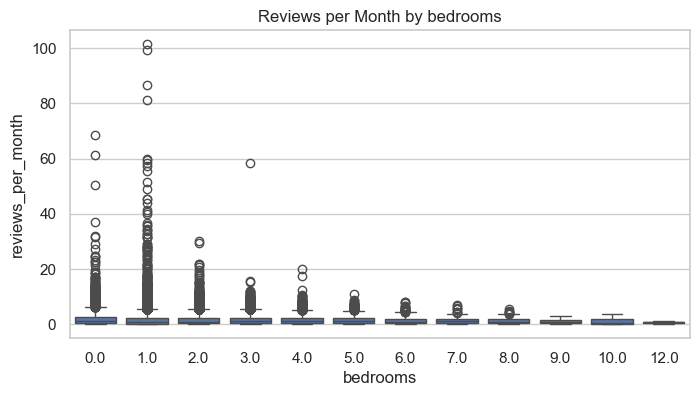

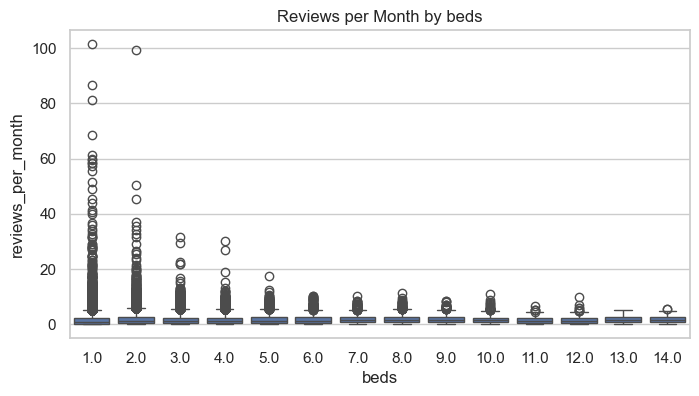

In [47]:
for col in structural_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df_clean, x=col, y='reviews_per_month')
    plt.title(f'Reviews per Month by {col}')
    plt.show()

### Amenity Analysis

In [48]:
amenity_cols = [col for col in df_clean.columns if col.startswith('amenity_')]

amenity_price_uplift = {}

for col in amenity_cols:
    if df_clean[col].nunique() == 2:
        uplift = df_clean.groupby(col)['price'].median().diff().iloc[-1]
        amenity_price_uplift[col] = uplift

amenity_price_uplift = pd.Series(amenity_price_uplift).sort_values(ascending=False)

amenity_price_uplift.head(20)

amenity_view_water        127.0
amenity_hot_tub           108.0
amenity_beach_access      107.0
amenity_pool               90.0
amenity_dishwasher         80.0
amenity_tv                 77.0
amenity_bbq_grill          77.0
amenity_washer             56.0
amenity_kitchen            55.0
amenity_patio_balcony      55.0
amenity_sound_system       55.0
amenity_fireplace          55.0
amenity_oven               54.0
amenity_dryer              52.0
amenity_blender            51.0
amenity_kids_amenities     50.0
amenity_ev_charger         50.0
amenity_view_nature        50.0
amenity_game_console       50.0
amenity_gym                48.0
dtype: float64

In [49]:
amenity_demand_uplift = {}

for col in amenity_cols:
    uplift = df_clean.groupby(col)['reviews_per_month'].median().diff().iloc[-1]
    amenity_demand_uplift[col] = uplift

pd.Series(amenity_demand_uplift).sort_values(ascending=False).head(20)

amenity_refrigerator         0.96
amenity_self_checkin         0.95
amenity_coffee_maker         0.93
amenity_cooking_basics       0.93
amenity_cleaning_supplies    0.89
amenity_microwave            0.86
amenity_bed_linens           0.84
amenity_hot_water            0.81
amenity_toaster              0.75
amenity_kids_amenities       0.74
amenity_fan                  0.71
amenity_toiletries           0.70
amenity_hair_dryer           0.68
amenity_parking_free         0.66
amenity_smoke_alarm          0.64
amenity_first_aid_kit        0.62
amenity_fire_extinguisher    0.60
amenity_wifi                 0.58
amenity_stove                0.58
amenity_private_entrance     0.55
dtype: float64

In [50]:
top_price_amenities = amenity_price_uplift.head(10).index.tolist()

top_price_amenities

['amenity_view_water',
 'amenity_hot_tub',
 'amenity_beach_access',
 'amenity_pool',
 'amenity_dishwasher',
 'amenity_tv',
 'amenity_bbq_grill',
 'amenity_washer',
 'amenity_kitchen',
 'amenity_patio_balcony']

In [51]:
# highest listing count
top_cities = df_clean['city'].value_counts().head(8).index.tolist()

top_cities

['Nyc',
 'Los Angeles',
 'Hawaii',
 'Broward',
 'Austin',
 'San Diego',
 'Clark County',
 'Nashville']

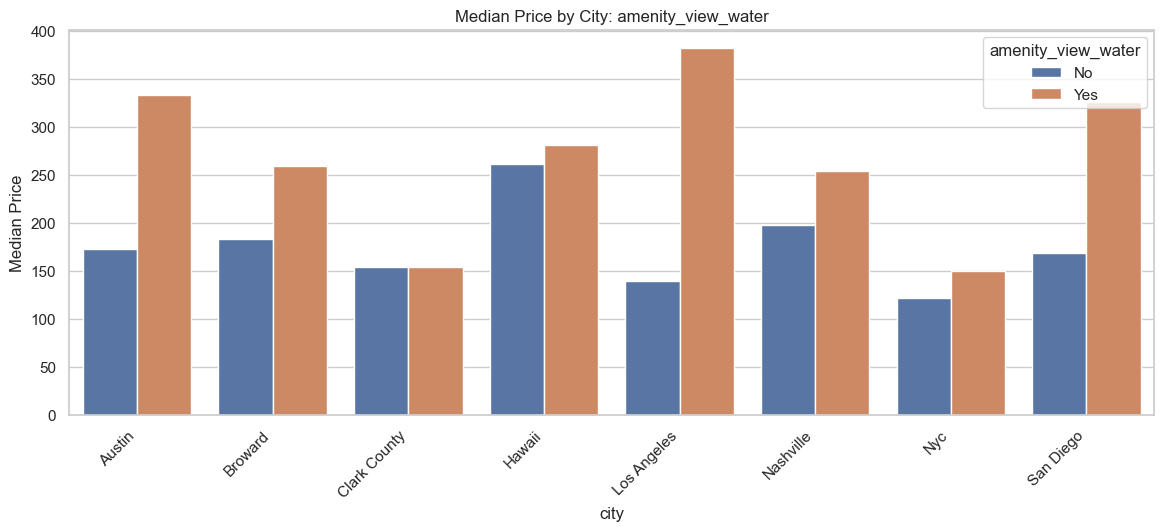

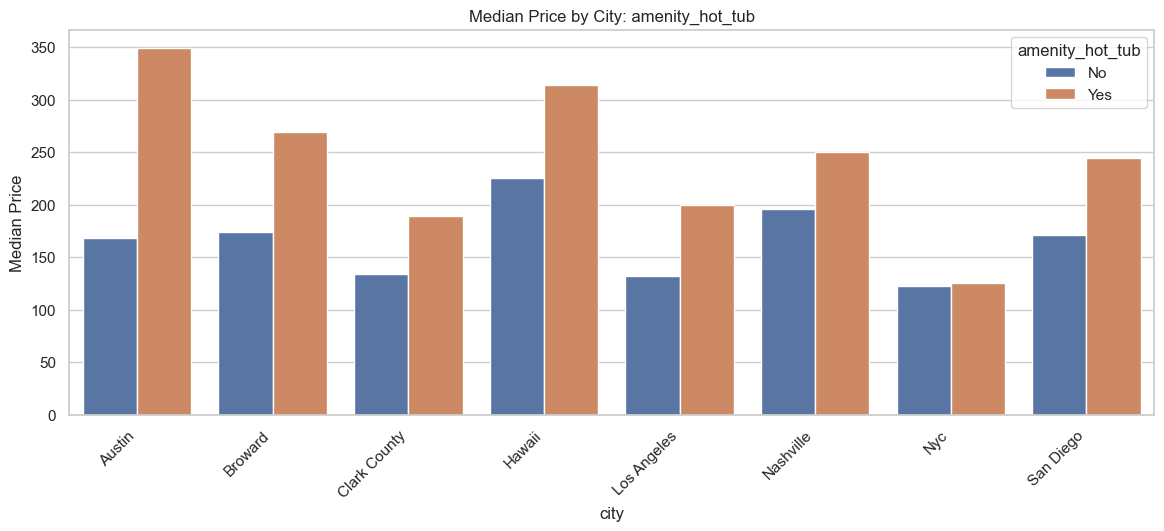

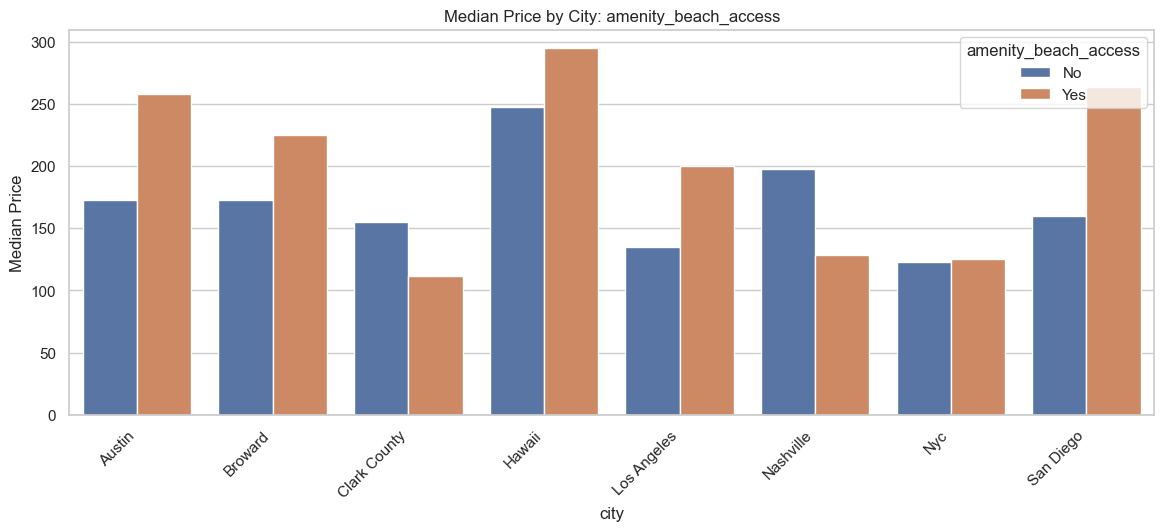

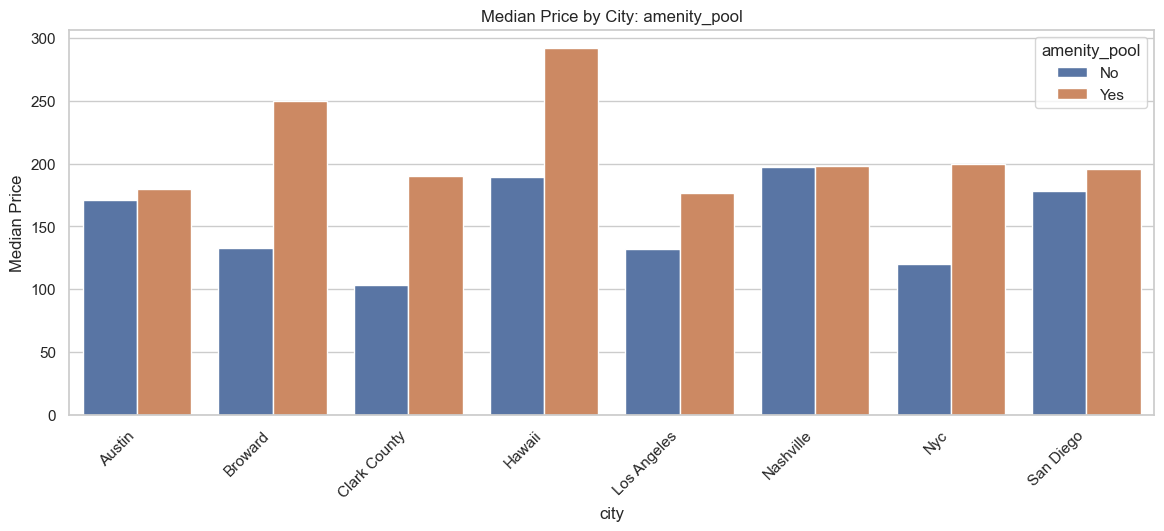

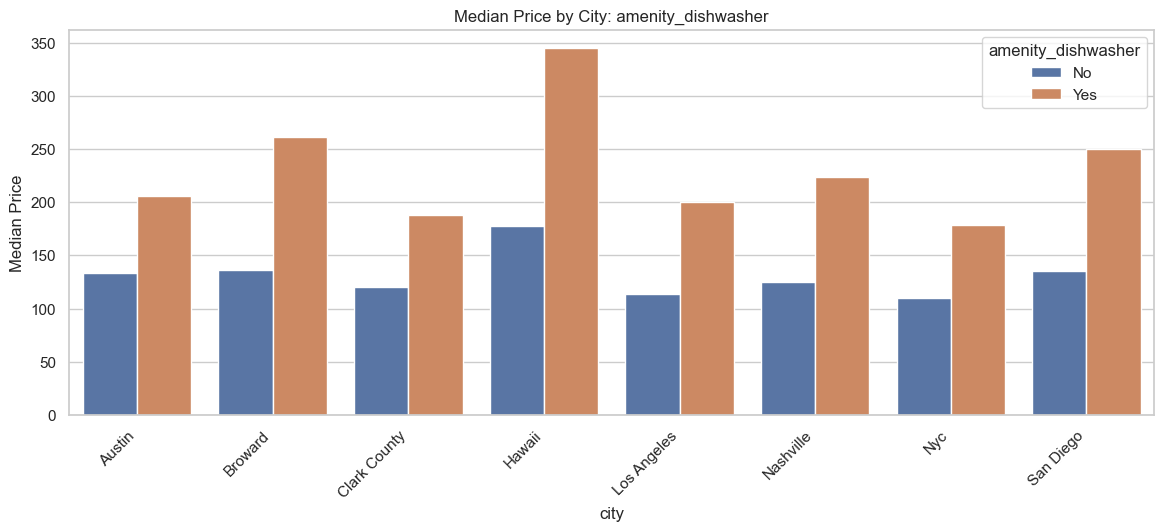

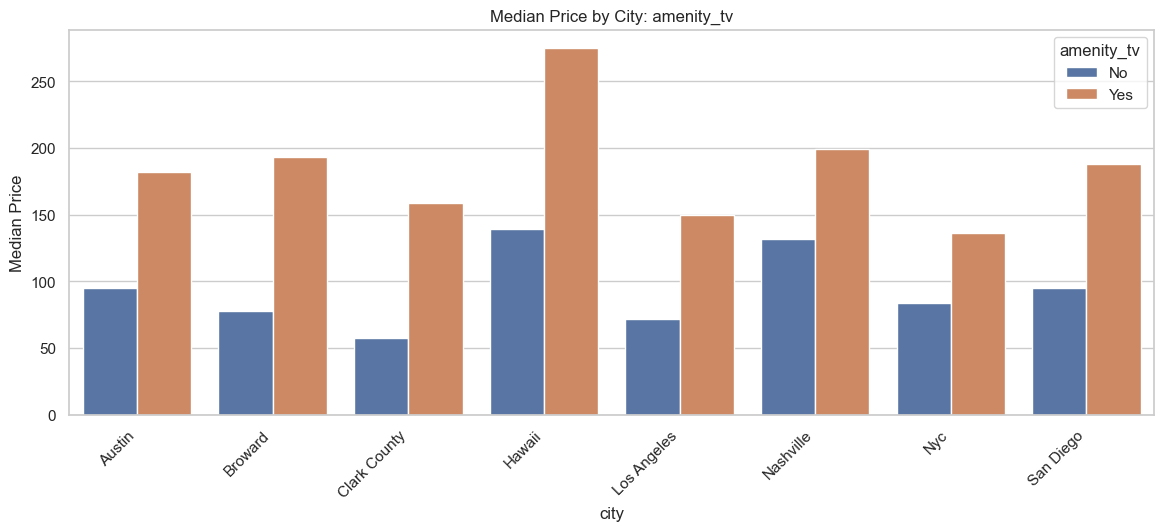

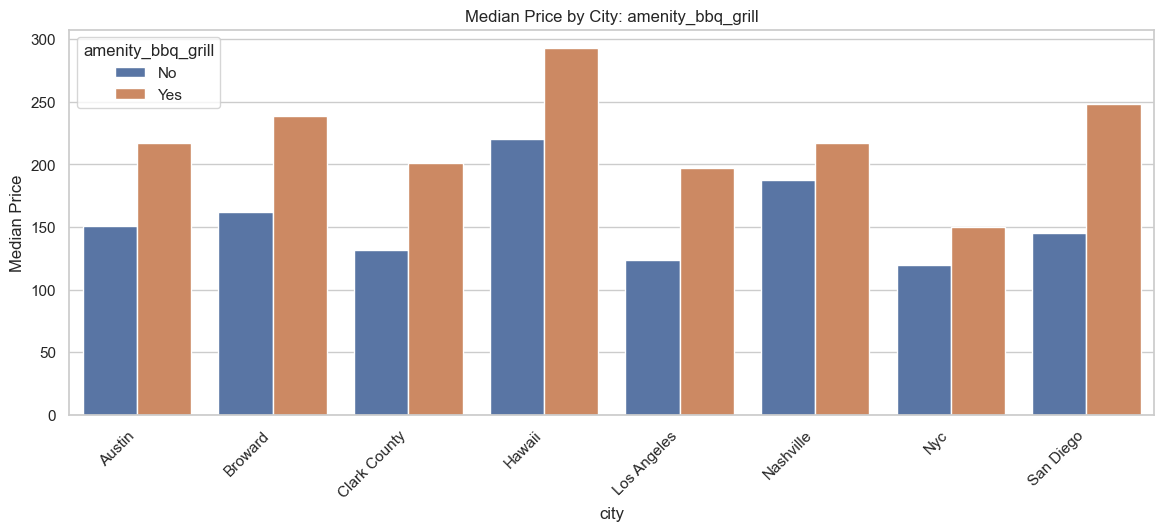

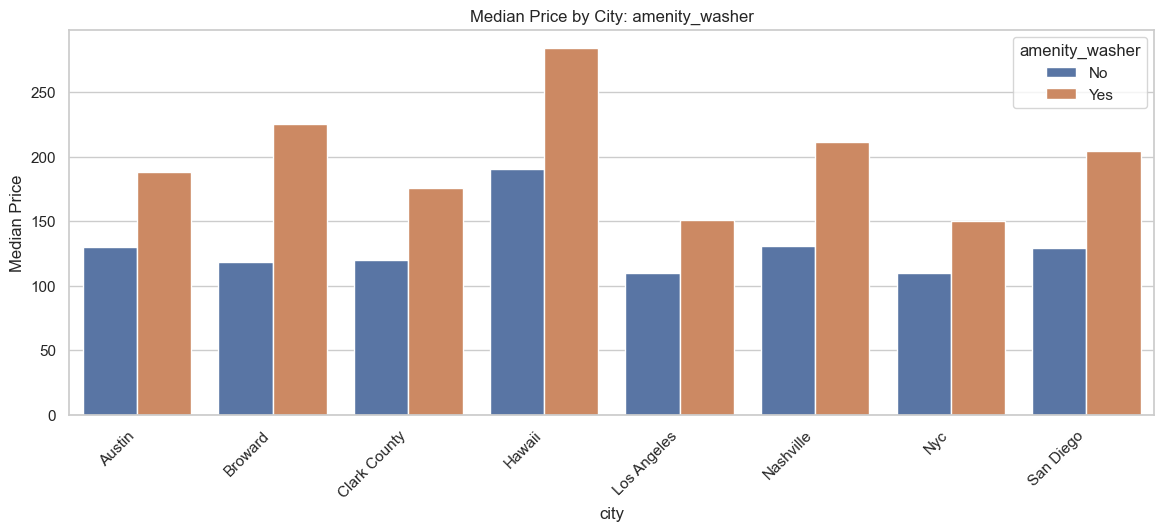

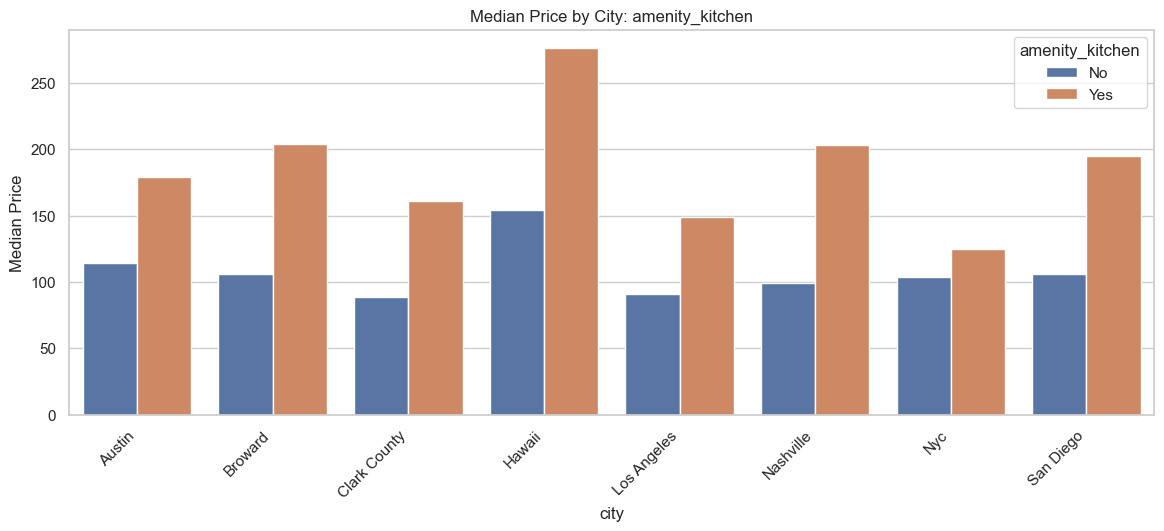

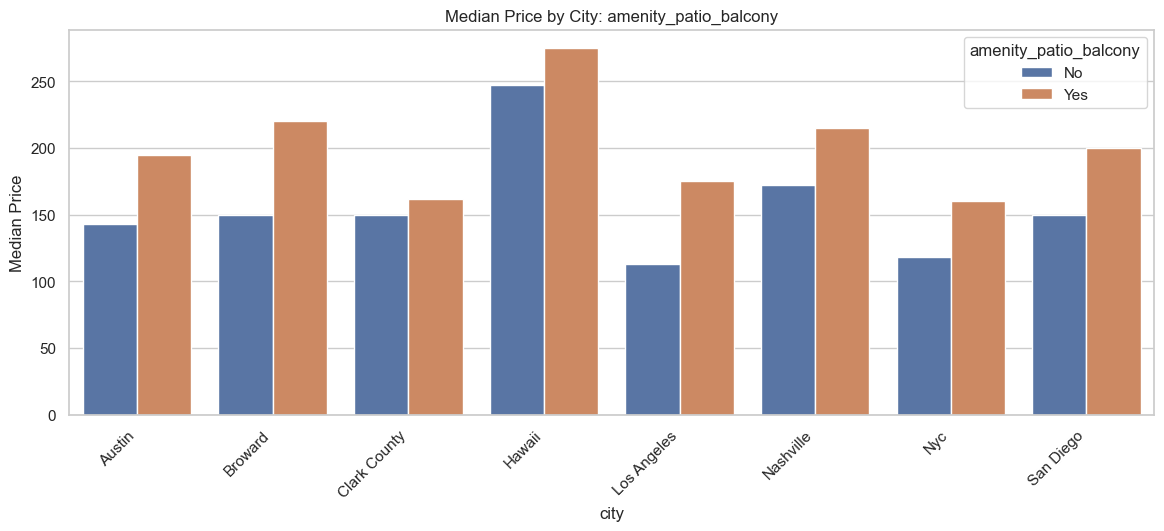

In [52]:
for amenity in top_price_amenities:

    plot_df = (
        df_clean[df_clean['city'].isin(top_cities)]
        .groupby(['city', amenity])['price']
        .median()
        .reset_index()
    )

    plot_df[amenity] = plot_df[amenity].map({
        0: 'No',
        1: 'Yes'
    })

    plt.figure(figsize=(14,5))

    sns.barplot(
        data=plot_df,
        x='city',
        y='price',
        hue=amenity
    )

    plt.title(f'Median Price by City: {amenity}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Median Price')
    plt.show()

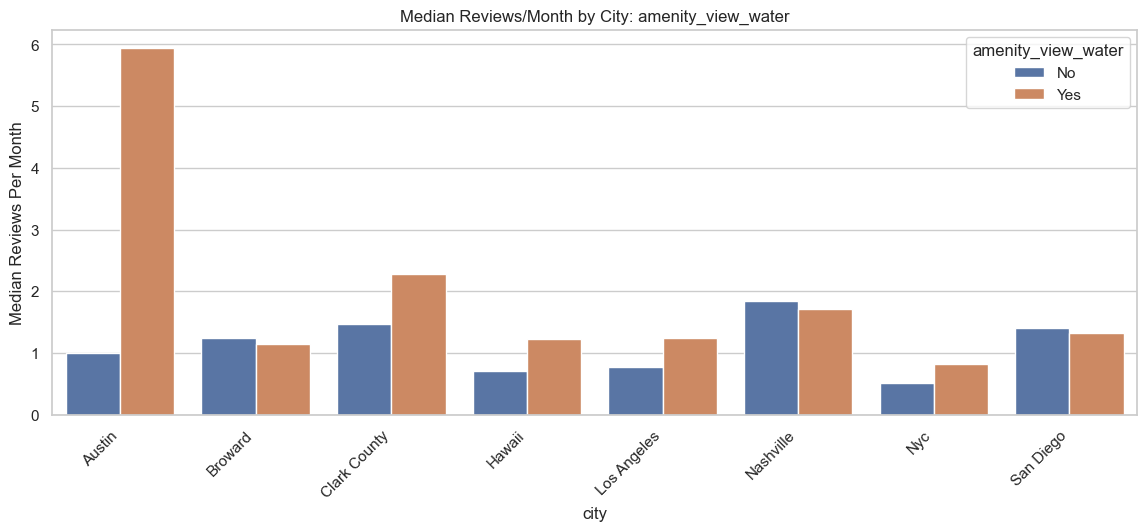

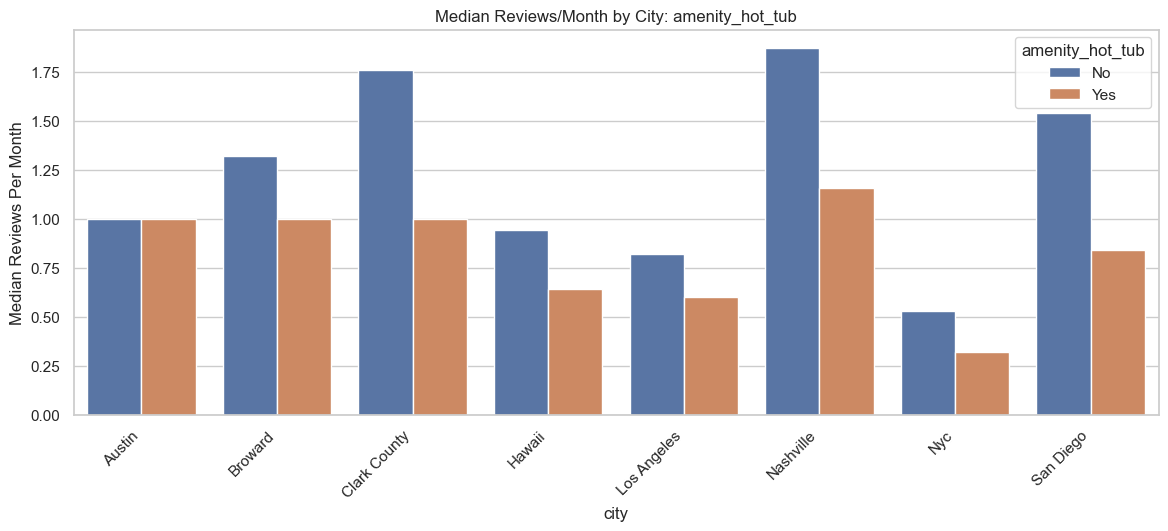

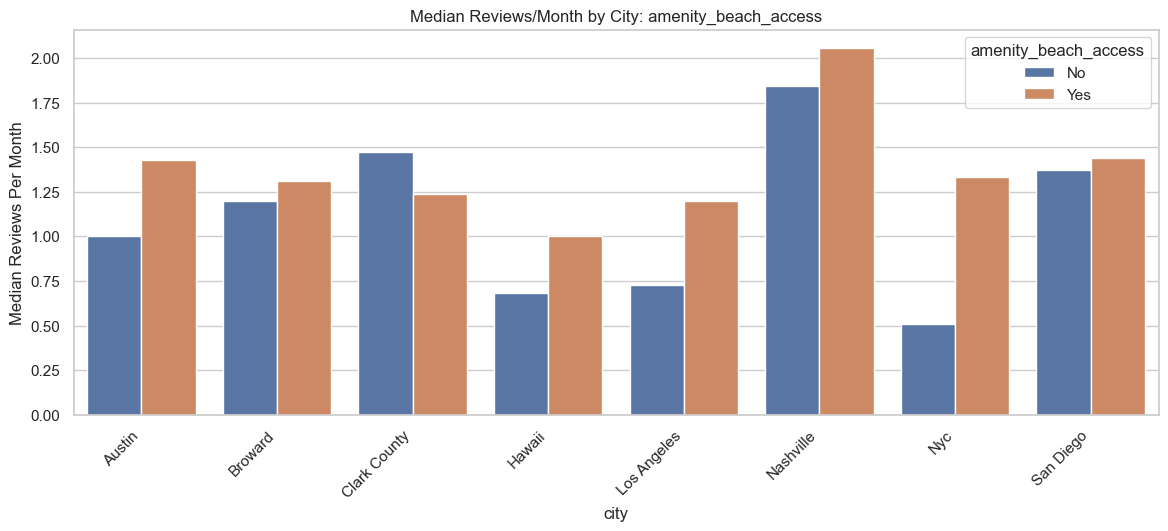

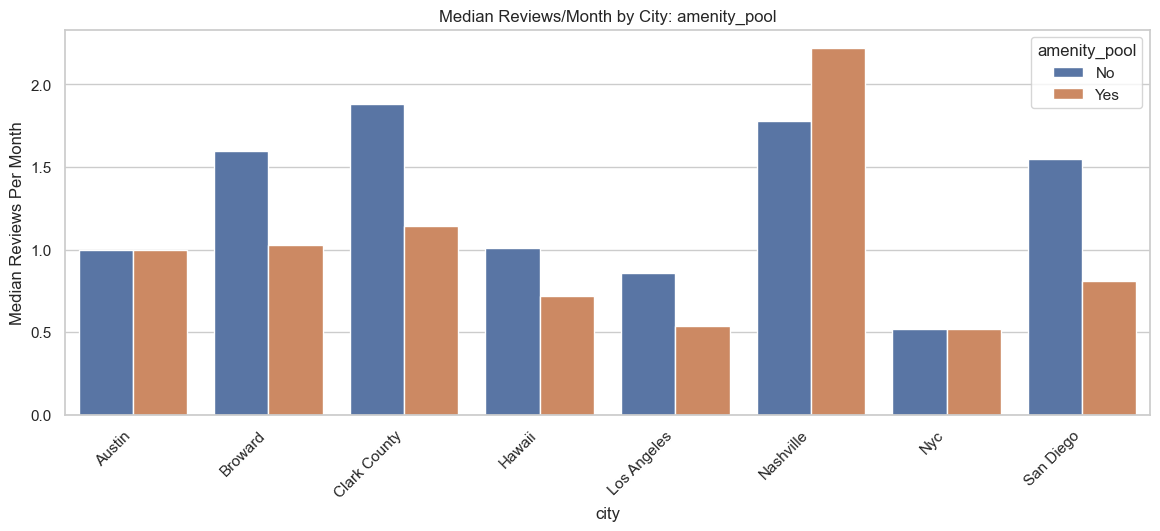

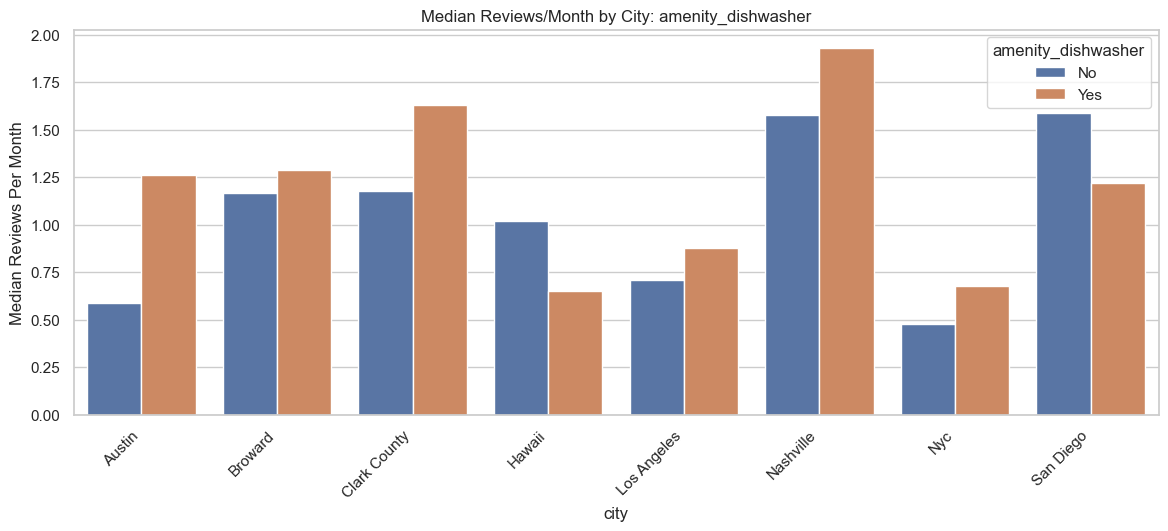

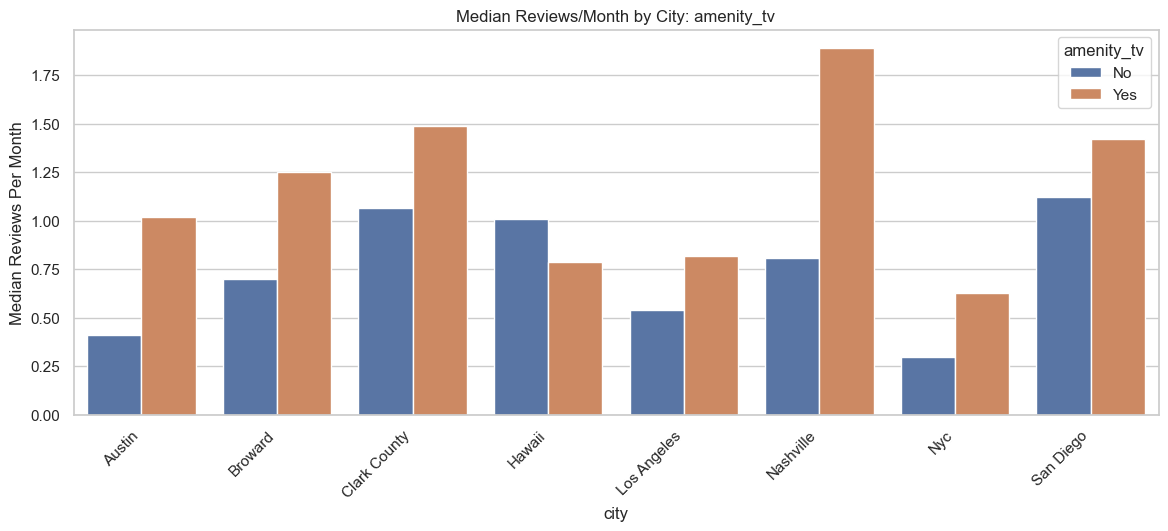

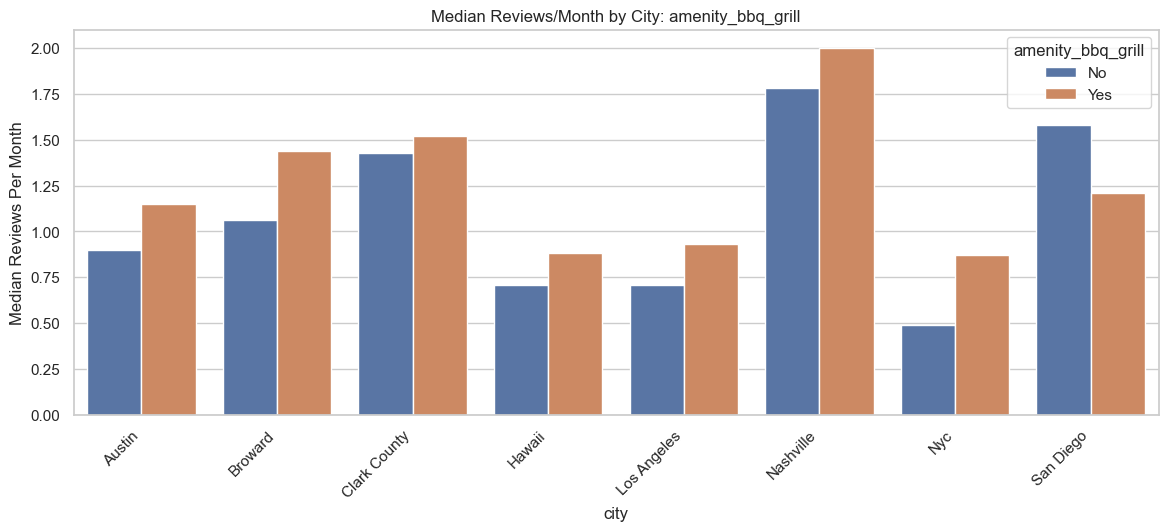

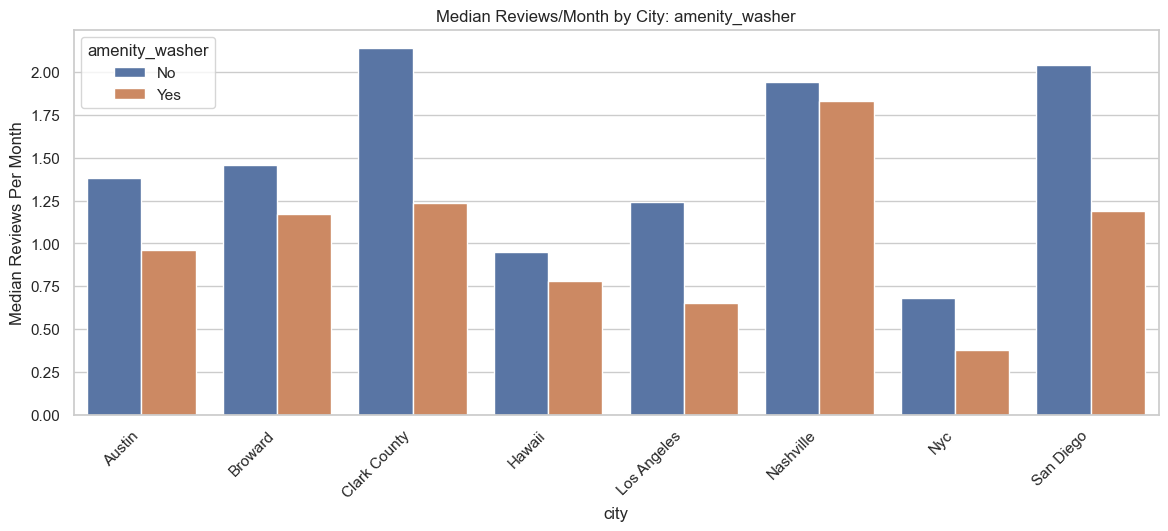

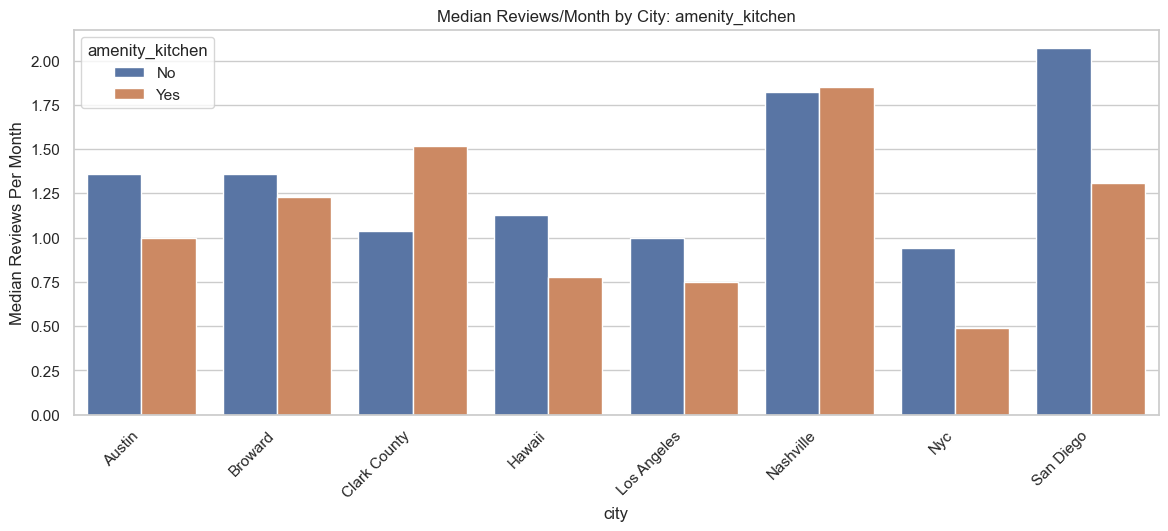

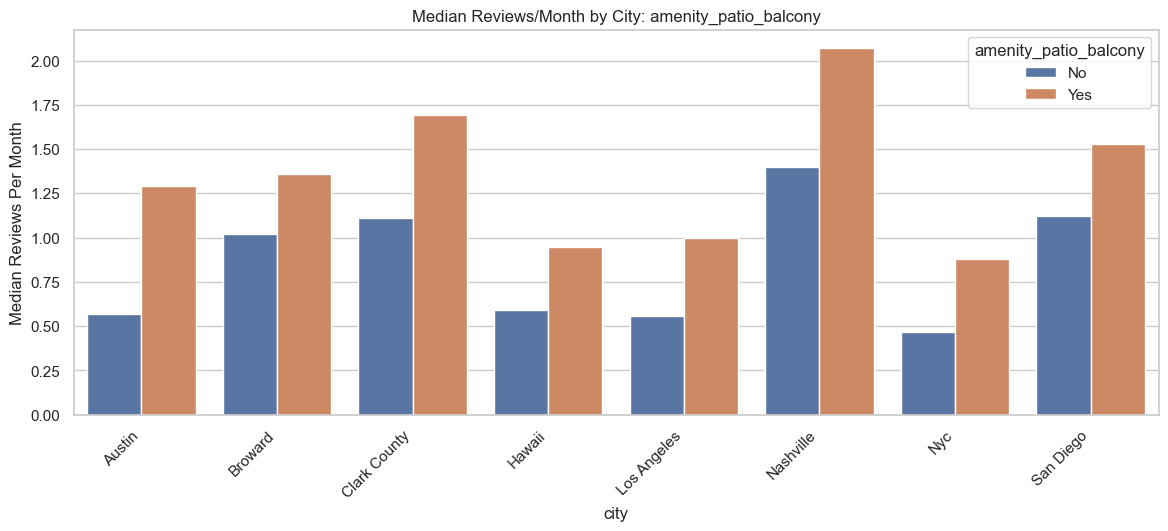

In [53]:
for amenity in top_price_amenities:

    plot_df = (
        df_clean[df_clean['city'].isin(top_cities)]
        .groupby(['city', amenity])['reviews_per_month']
        .median()
        .reset_index())

    plot_df[amenity] = plot_df[amenity].map({
        0: 'No',
        1: 'Yes'})

    plt.figure(figsize=(14,5))

    sns.barplot(
        data=plot_df,
        x='city',
        y='reviews_per_month',
        hue=amenity)

    plt.title(f'Median Reviews/Month by City: {amenity}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Median Reviews Per Month')
    plt.show()

In [54]:
amenity_cols = [col for col in df.columns if col.startswith('amenity_')]

amenity_freq_df = (
    df_clean[amenity_cols]
    .mean()
    .sort_values(ascending=False)
    .to_frame(name='pct_of_listings'))

display(amenity_freq_df.head(15))

,pct_of_listings
amenity_wifi,0.986985
amenity_smoke_alarm,0.950733
amenity_essentials,0.916699
amenity_kitchen,0.902767
amenity_tv,0.890559
amenity_air_conditioning,0.839021
amenity_hangers,0.837349
amenity_cooking_basics,0.829925
amenity_refrigerator,0.829061
amenity_hair_dryer,0.821451


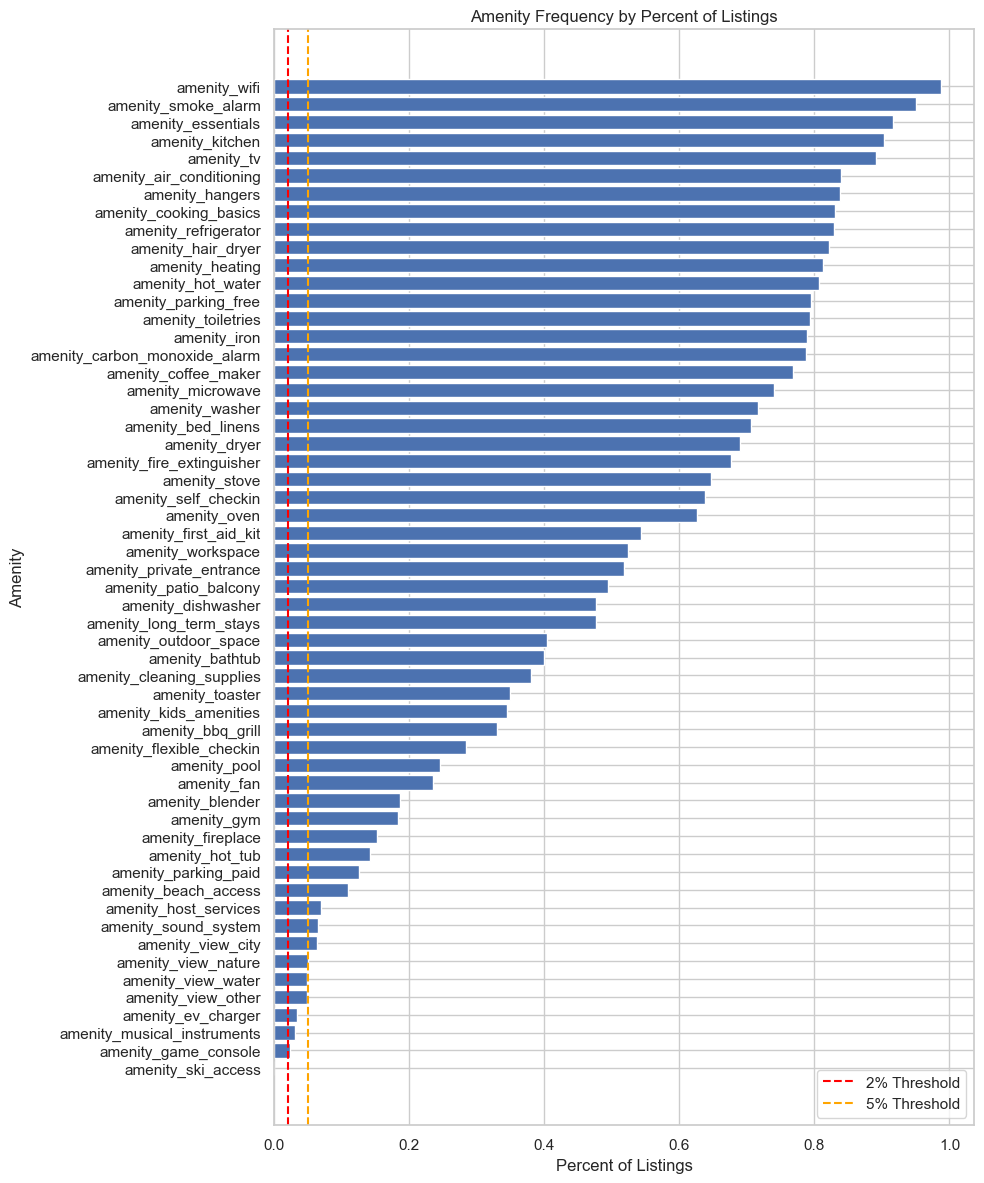

In [55]:
amenity_freq_sorted = amenity_freq_df.sort_values(by='pct_of_listings')

plt.figure(figsize=(10, 12))
plt.barh(
    amenity_freq_sorted.index,
    amenity_freq_sorted['pct_of_listings'])

plt.axvline(0.02, color='red', linestyle='--', label='2% Threshold')
plt.axvline(0.05, color='orange', linestyle='--', label='5% Threshold')

plt.title('Amenity Frequency by Percent of Listings')
plt.xlabel('Percent of Listings')
plt.ylabel('Amenity')
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
# selecting amenity columns to compare against price
amenity_cols = [col for col in df_clean.columns if col.startswith('amenity_')]

# keeping amenities that appear often enough to compare
selected_amenities = [
    col for col in amenity_cols
    if df_clean[col].mean() >= 0.05]

print('Amenity columns:', len(amenity_cols))
print('Selected amenities:', len(selected_amenities))

selected_amenities[:10]

Amenity columns: 56
Selected amenities: 49


['amenity_air_conditioning',
 'amenity_bathtub',
 'amenity_bbq_grill',
 'amenity_beach_access',
 'amenity_bed_linens',
 'amenity_blender',
 'amenity_carbon_monoxide_alarm',
 'amenity_cleaning_supplies',
 'amenity_coffee_maker',
 'amenity_cooking_basics']

In [57]:
# comparing price and demand for listings with and without each amenity
amenity_summary = []

for amenity in selected_amenities:
    yes = df_clean[df_clean[amenity] == 1]
    no = df_clean[df_clean[amenity] == 0]

    amenity_summary.append({
        'amenity': amenity,
        'frequency': df_clean[amenity].mean(),
        'median_price_yes': yes['price'].median(),
        'median_price_no': no['price'].median(),
        'median_price_lift': yes['price'].median() - no['price'].median(),
        'median_demand_yes': yes['reviews_per_month'].median(),
        'median_demand_no': no['reviews_per_month'].median(),
        'median_demand_lift': yes['reviews_per_month'].median() - no['reviews_per_month'].median()})

amenity_summary_df = pd.DataFrame(amenity_summary)

amenity_summary_df.sort_values('median_demand_lift', ascending=False).head(15)

,amenity,frequency,median_price_yes,median_price_no,median_price_lift,median_demand_yes,median_demand_no,median_demand_lift
37,amenity_refrigerator,0.829061,155.0,125.0,30.0,1.23,0.27,0.96
38,amenity_self_checkin,0.637739,158.0,137.0,21.0,1.43,0.48,0.95
8,amenity_coffee_maker,0.768868,161.0,115.0,46.0,1.28,0.35,0.93
9,amenity_cooking_basics,0.829925,157.0,120.0,37.0,1.21,0.28,0.93
7,amenity_cleaning_supplies,0.380644,154.0,149.0,5.0,1.62,0.73,0.89
29,amenity_microwave,0.740102,158.0,130.0,28.0,1.28,0.42,0.86
4,amenity_bed_linens,0.706591,158.0,131.0,27.0,1.31,0.47,0.84
24,amenity_hot_water,0.806175,150.0,145.0,5.0,1.21,0.40,0.81
42,amenity_toaster,0.349550,171.0,140.0,31.0,1.54,0.79,0.75
26,amenity_kids_amenities,0.344648,185.0,135.0,50.0,1.54,0.80,0.74


In [58]:
# low frequency, higher demand lift amenities
amenity_summary_df[
    (amenity_summary_df['frequency'] < 0.10) &
    (amenity_summary_df['median_demand_lift'] > 0.5)].sort_values('median_demand_lift', ascending=False).head(15)

,amenity,frequency,median_price_yes,median_price_no,median_price_lift,median_demand_yes,median_demand_no,median_demand_lift
45,amenity_view_city,0.063475,189.0,149.0,40.0,1.53,1.0,0.53


In [59]:
amenity_summary_df[
    (amenity_summary_df['frequency'] < 0.10) &
    (amenity_summary_df['median_price_lift'] > 50)].sort_values('median_price_lift', ascending=False).head(15)

,amenity,frequency,median_price_yes,median_price_no,median_price_lift,median_demand_yes,median_demand_no,median_demand_lift
40,amenity_sound_system,0.065237,204.0,149.0,55.0,1.33,1.0,0.33


### Amenity Review

Amenity frequency helped me see which features are common across listings, but frequency is inconclusive. I also looked at price premium and demand lift to see whether certain amenities were tied to higher prices or stronger booking activity.

The price comparison was somewhat useful, but not enough on its own. It makes sense that listings with more premium amenities can often charge more. The issue is that this does not tell me whether the amenity is driving the price, or if the listing is just larger, better located, or part of a stronger market.

Demand was more interesting because some amenities seemed to matter more in certain cities than others. This could mean amenity value is market-specific.

Overall, this section is helpful for spotting patterns, but it is not conclusive. I would be more interested in which amenity combinations help listings stay consistently booked.

### Explore Host Features

In [60]:
quality_features = [
    'host_is_superhost',
    'instant_bookable',
    'host_response_time_ord',
    'review_scores_rating']

df_clean[quality_features + ['price']].describe(include='all')

,host_is_superhost,instant_bookable,host_response_time_ord,review_scores_rating,price
count,210525.000000,210525.000000,210525.000000,210525.000000,210525.000000
mean,0.417746,0.317915,2.186301,4.732237,214.855509
std,0.493189,0.465667,1.443501,0.521867,211.986930
min,0.000000,0.000000,-1.000000,0.000000,0.000000
25%,0.000000,0.000000,2.000000,4.680000,95.000000
50%,0.000000,0.000000,3.000000,4.880000,150.000000
75%,1.000000,1.000000,3.000000,5.000000,253.000000
max,1.000000,1.000000,3.000000,5.000000,2000.000000


In [61]:
from scipy.stats import ttest_ind

binary_quality_features = ['host_is_superhost', 'instant_bookable']

for col in binary_quality_features:
    yes_group = df[df[col] == 1]['price'].dropna()
    no_group = df[df[col] == 0]['price'].dropna()

    stat, p = ttest_ind(yes_group, no_group, equal_var=False)

    print(f'\n--- {col.replace("_", " ").title()} ---')
    print(f'Mean price when TRUE: ${yes_group.mean():.2f}')
    print(f'Median price when TRUE: ${yes_group.median():.2f}')
    print(f'Mean price when FALSE: ${no_group.mean():.2f}')
    print(f'Median price when FALSE: ${no_group.median():.2f}')
    print(f'p-value: {p:.10f}')


--- Host Is Superhost ---
Mean price when TRUE: $246.96
Median price when TRUE: $162.00
Mean price when FALSE: $243.43
Median price when FALSE: $145.00
p-value: 0.3874093679

--- Instant Bookable ---
Mean price when TRUE: $280.65
Median price when TRUE: $175.00
Mean price when FALSE: $228.18
Median price when FALSE: $144.00
p-value: 0.0000000000


In [62]:
from scipy.stats import ttest_ind

# using normal price so the results are easier to interpret
price_col = 'price'

ttest_results = []

for col in binary_quality_features:
    group_yes = df_clean[df_clean[col] == 1][price_col].dropna()
    group_no = df_clean[df_clean[col] == 0][price_col].dropna()

    stat, p = ttest_ind(group_yes, group_no, equal_var=False)

    ttest_results.append({
        'feature': col,
        'mean_price_yes': group_yes.mean(),
        'mean_price_no': group_no.mean(),
        'price_difference': group_yes.mean() - group_no.mean(),
        'p_value': p
    })

ttest_results_df = (
    pd.DataFrame(ttest_results)
    .sort_values('price_difference', ascending=False)
    .round(4)
)

ttest_results_df

,feature,mean_price_yes,mean_price_no,price_difference,p_value
1,instant_bookable,240.0001,203.1358,36.8643,0.0
0,host_is_superhost,227.5143,205.7733,21.7410,0.0


In [63]:
df_clean['host_response_time_ord'].value_counts(dropna=False)

host_response_time_ord
 3.0    146759
-1.0     31366
 2.0     20701
 1.0      9958
 0.0      1741
Name: count, dtype: int64

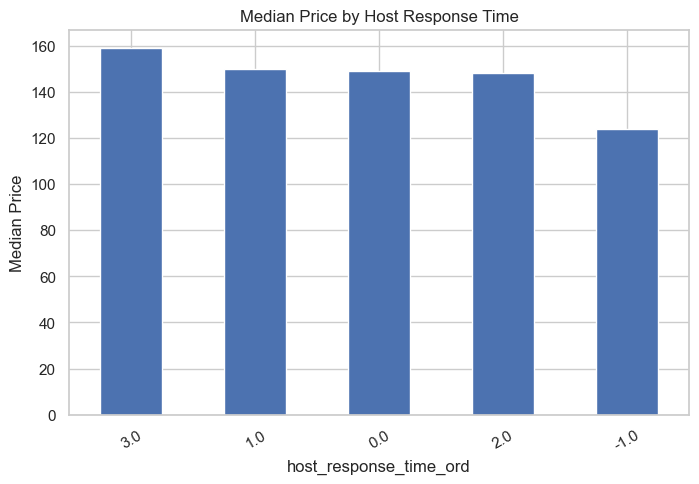

In [64]:
response_medians = (
    df.groupby('host_response_time_ord')['price']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
response_medians.plot(kind='bar')
plt.title('Median Price by Host Response Time')
plt.ylabel('Median Price')
plt.xticks(rotation=30)
plt.show()

In [65]:
df_clean['review_scores_rating'].describe()

count    210525.000000
mean          4.732237
std           0.521867
min           0.000000
25%           4.680000
50%           4.880000
75%           5.000000
max           5.000000
Name: review_scores_rating, dtype: float64

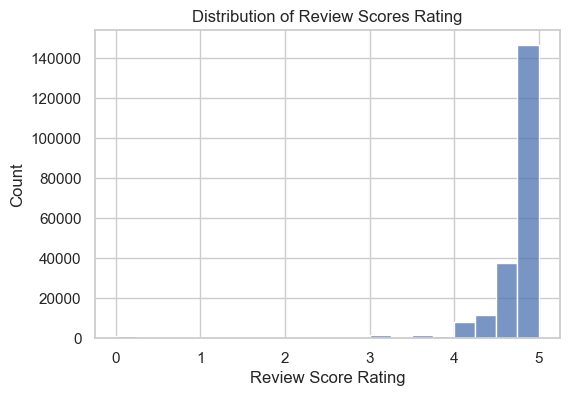

In [66]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean['review_scores_rating'].dropna(), bins=20)
plt.title('Distribution of Review Scores Rating')
plt.xlabel('Review Score Rating')
plt.show()

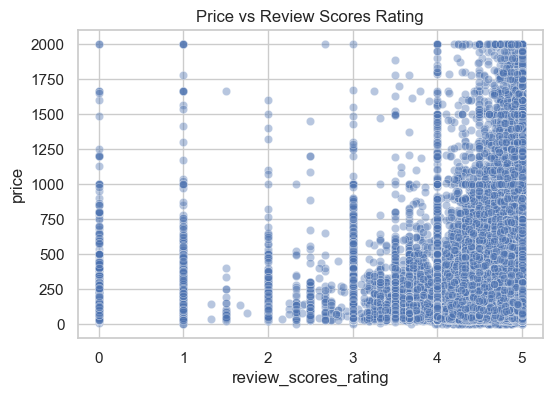

In [67]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x='review_scores_rating', y='price', alpha=0.4)
plt.title('Price vs Review Scores Rating')
plt.show()

In [68]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df_clean['host_is_superhost'], df_clean['instant_bookable'])
display(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f'Chi-square statistic: {chi2:.3f}')
print(f'p-value: {p:.10f}')

instant_bookable,0,1
host_is_superhost,,
0.0,81735,40844
1.0,61861,26085


Chi-square statistic: 316.215
p-value: 0.0000000000


In [69]:
contingency = pd.crosstab(df_clean['host_is_superhost'], df_clean['host_response_time_ord'])
display(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f'Chi-square statistic: {chi2:.3f}')
print(f'p-value: {p:.10f}')

host_response_time_ord,-1.0,0.0,1.0,2.0,3.0
host_is_superhost,,,,,
0.0,29034,1663,7363,12046,72473
1.0,2332,78,2595,8655,74286


Chi-square statistic: 21931.468
p-value: 0.0000000000


In [70]:
quality_summary = []

for col in ['host_is_superhost', 'instant_bookable']:
    group_yes = df[df[col] == 1]['price']
    group_no = df[df[col] == 0]['price']

    quality_summary.append({
        'feature': col,
        'median_price_yes': group_yes.median(),
        'median_price_no': group_no.median(),
        'median_difference': group_yes.median() - group_no.median(),
        'mean_price_yes': group_yes.mean(),
        'mean_price_no': group_no.mean(),
        'mean_difference': group_yes.mean() - group_no.mean(),
        'frequency_yes': df[col].mean()
    })

quality_summary_df = pd.DataFrame(quality_summary)
display(quality_summary_df)

,feature,median_price_yes,median_price_no,median_difference,mean_price_yes,mean_price_no,mean_difference,frequency_yes
0,host_is_superhost,162.0,145.0,17.0,246.955683,243.429166,3.526517,0.417395
1,instant_bookable,175.0,144.0,31.0,280.654253,228.181887,52.472366,0.318629


In [71]:
df_clean.columns

Index(['id', 'host_id', 'room_type_hotel_room', 'room_type_private_room',
       'room_type_shared_room', 'accommodates', 'bedrooms', 'beds',
       'bathrooms', 'host_is_superhost', 'host_response_time_ord', 'price',
       'latitude', 'longitude', 'number_of_reviews', 'reviews_per_month',
       'review_scores_rating', 'instant_bookable', 'amenity_air_conditioning',
       'amenity_bathtub', 'amenity_bbq_grill', 'amenity_beach_access',
       'amenity_bed_linens', 'amenity_blender',
       'amenity_carbon_monoxide_alarm', 'amenity_cleaning_supplies',
       'amenity_coffee_maker', 'amenity_cooking_basics', 'amenity_dishwasher',
       'amenity_dryer', 'amenity_essentials', 'amenity_ev_charger',
       'amenity_fan', 'amenity_fire_extinguisher', 'amenity_fireplace',
       'amenity_first_aid_kit', 'amenity_flexible_checkin',
       'amenity_game_console', 'amenity_gym', 'amenity_hair_dryer',
       'amenity_hangers', 'amenity_heating', 'amenity_host_services',
       'amenity_hot_tub'

In [72]:
df_clean.shape

(210525, 82)

In [73]:
df_clean.to_csv('../data/processed/airbnb_eda_clean.csv', index=False)

### Analysis
* The mean price for superhost vs not superhost was interesting since it was higher. There could be some large/luxury listings driving up the mean, where the host is not a superhost.
* I think it makes most sense to focus on median when analyzing the Airbnb listings.

## Modeling Implications / Feature Selection

### Dataset Preparation Summary
1. Removed inactive / extreme commercial listings (skewing data)
2. Applied percentile-based outlier filter

### Key Findings
* Larger listings = higher prices but are book less often, suggesting a tradeoff between ADR and demand.
* Premium amenities like water views, beach access, hot tubs, and pools are linked to with the largest price premiums.
* Convenience/basic-use amenities appear more strongly associated with booking frequency than luxury amenities.
* Location impacts both price and booking performance -- will look further into this
* convenience amenities drive booking frequency
* host/listing quality features show modest relationship

Based on EDA, the most predictive variables for price and booking performance are property attributes (beds/room type), location, and select amenities which I will look into when modeling.


### Features to Keep for Modeling
* Capacity: accommodates, bedrooms, bathrooms
* Location: city, lat/long
* Listing type: room type (entire place, shared, private)
* Premium amenities with high price signal
* Host/listing quality features (superhost, instant bookable, review rating)

### Features Excluded / Reduced
* IDs / URLs / non-predictive metadata
* Highly sparse amenities (less than 5% of listings)
* Basic/common amenities with little differentiating power

### Next Steps
1. Prep selected features for predictive modeling
2. Address multicollinearity among correlated variables (beds, bedrooms, bathrooms)
3. Test regression models
4. Evaluate model performance to identify the strongest drivers of Airbnb pricing
5. Add image analysis

In [74]:
sns.set_theme(style='whitegrid', palette='Set2')
set2_colors = sns.color_palette('Set2')

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

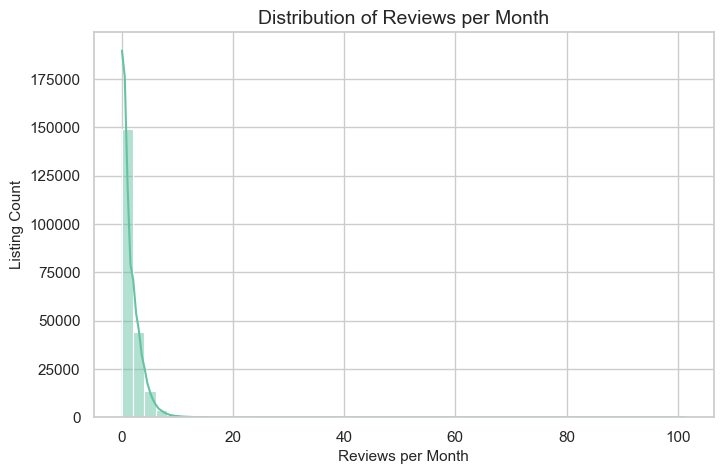

In [75]:
# checking the demand distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='reviews_per_month',
    bins=50,
    kde=True,
    color=set2_colors[0]
)

plt.title('Distribution of Reviews per Month')
plt.xlabel('Reviews per Month')
plt.ylabel('Listing Count')
plt.show()

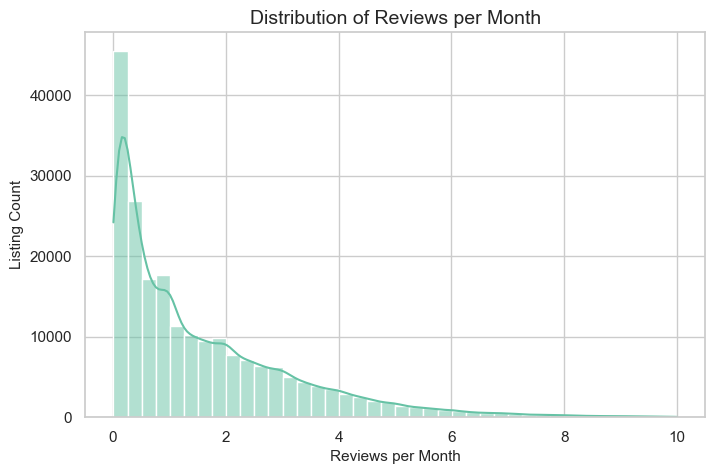

In [76]:
# capping the x-axis so the demand pattern is easier to read
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df[df['reviews_per_month'] <= 10],
    x='reviews_per_month',
    bins=40,
    kde=True,
    color=set2_colors[0]
)

plt.title('Distribution of Reviews per Month')
plt.xlabel('Reviews per Month')
plt.ylabel('Listing Count')
plt.show()

In [78]:
df.columns

Index(['id', 'host_id', 'room_type_hotel_room', 'room_type_private_room',
       'room_type_shared_room', 'accommodates', 'bedrooms', 'beds',
       'bathrooms', 'host_is_superhost', 'host_response_time_ord', 'price',
       'latitude', 'longitude', 'number_of_reviews', 'reviews_per_month',
       'review_scores_rating', 'instant_bookable', 'amenity_air_conditioning',
       'amenity_bathtub', 'amenity_bbq_grill', 'amenity_beach_access',
       'amenity_bed_linens', 'amenity_blender',
       'amenity_carbon_monoxide_alarm', 'amenity_cleaning_supplies',
       'amenity_coffee_maker', 'amenity_cooking_basics', 'amenity_dishwasher',
       'amenity_dryer', 'amenity_essentials', 'amenity_ev_charger',
       'amenity_fan', 'amenity_fire_extinguisher', 'amenity_fireplace',
       'amenity_first_aid_kit', 'amenity_flexible_checkin',
       'amenity_game_console', 'amenity_gym', 'amenity_hair_dryer',
       'amenity_hangers', 'amenity_heating', 'amenity_host_services',
       'amenity_hot_tub'

C:\Users\cococ\AppData\Local\Temp\ipykernel_17052\615214989.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


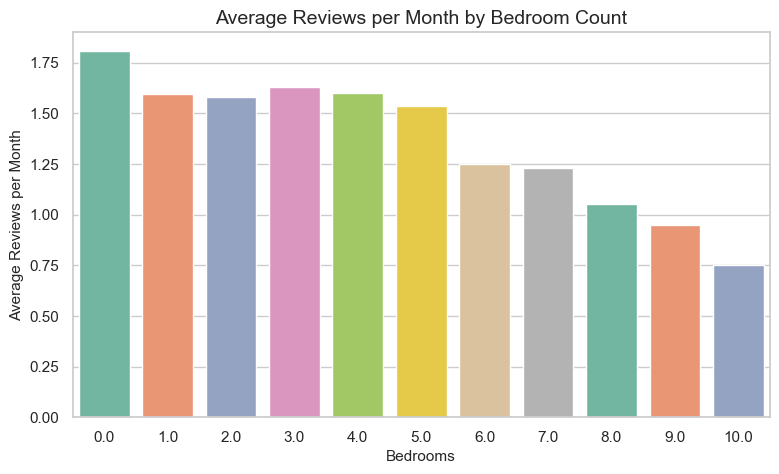

,bedrooms,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,0.0,18502,1.81,1.06,175.94
1,1.0,103051,1.59,0.94,157.41
2,2.0,46560,1.58,1.00,264.47
3,3.0,26174,1.63,1.19,353.90
4,4.0,11784,1.60,1.25,497.40
5,5.0,3765,1.54,1.21,687.40
6,6.0,1262,1.25,0.91,968.25
7,7.0,419,1.23,1.00,1274.41
8,8.0,292,1.05,0.66,1117.64
9,9.0,84,0.95,0.74,1331.55


In [80]:
# comparing demand by bedroom count
bedroom_demand = (
    df
    .groupby('bedrooms')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

bedroom_demand = bedroom_demand[bedroom_demand['listing_count'] >= 30]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=bedroom_demand,
    x='bedrooms',
    y='avg_reviews_per_month',
    palette='Set2'
)

plt.title('Average Reviews per Month by Bedroom Count')
plt.xlabel('Bedrooms')
plt.ylabel('Average Reviews per Month')
plt.show()

bedroom_demand.round(2)

C:\Users\cococ\AppData\Local\Temp\ipykernel_17052\2268471807.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


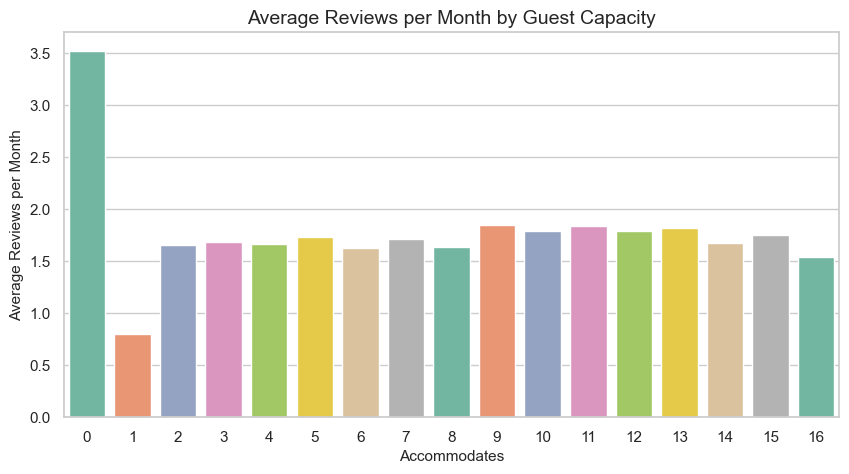

,accommodates,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,0,30,3.52,0.85,0.00
1,1,14134,0.80,0.37,89.58
2,2,64474,1.65,0.98,152.63
3,3,15721,1.68,1.00,152.93
4,4,47059,1.67,1.05,217.20
5,5,10448,1.73,1.21,247.50
6,6,27419,1.62,1.09,335.15
7,7,3850,1.71,1.24,321.55
8,8,12856,1.64,1.17,437.07
9,9,1592,1.85,1.50,387.88


In [82]:
# comparing demand by guest capacity
capacity_demand = (
    df
    .groupby('accommodates')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

capacity_demand = capacity_demand[capacity_demand['listing_count'] >= 30]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=capacity_demand,
    x='accommodates',
    y='avg_reviews_per_month',
    palette='Set2'
)

plt.title('Average Reviews per Month by Guest Capacity')
plt.xlabel('Accommodates')
plt.ylabel('Average Reviews per Month')
plt.show()

capacity_demand.round(2)

C:\Users\cococ\AppData\Local\Temp\ipykernel_17052\2333844812.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


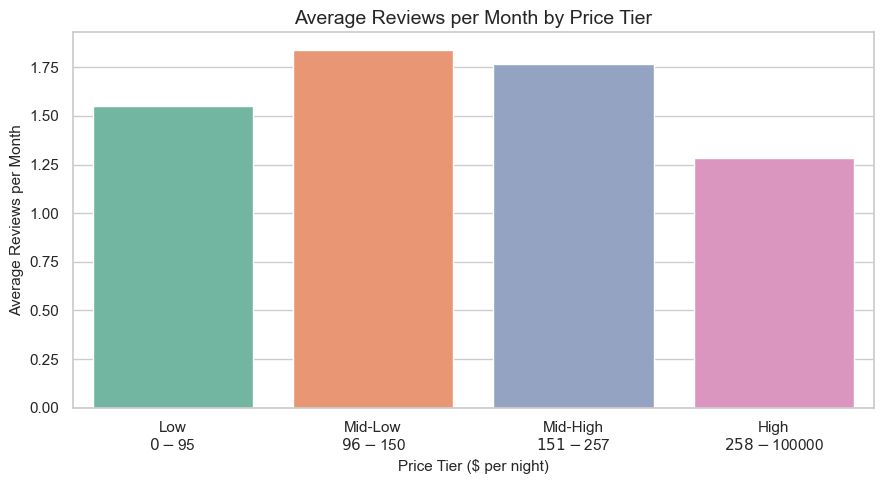

,price_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,min_price,max_price,price_tier_label
0,Low,53953,1.55,0.87,66.47,0.0,95.0,Low\n$0 - $95
1,Mid-Low,52884,1.84,1.22,122.39,96.0,150.0,Mid-Low\n$96 - $150
2,Mid-High,52251,1.77,1.23,197.88,151.0,257.0,Mid-High\n$151 - $257
3,High,52939,1.28,0.85,595.54,258.0,100000.0,High\n$258 - $100000


In [88]:
# grouping listings into price tiers with visible price ranges
df_plot = df.copy()

df_plot['price_tier'] = pd.qcut(
    df_plot['price'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

price_tier_summary = (
    df_plot
    .groupby('price_tier', observed=True)
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'),
        min_price=('price', 'min'),
        max_price=('price', 'max')
    )
    .reset_index()
)

# creating labels that show each price tier range
price_tier_summary['price_tier_label'] = (
    price_tier_summary['price_tier'].astype(str) +
    '\n$' + price_tier_summary['min_price'].round(0).astype(int).astype(str) +
    ' - $' + price_tier_summary['max_price'].round(0).astype(int).astype(str)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=price_tier_summary,
    x='price_tier_label',
    y='avg_reviews_per_month',
    palette='Set2'
)

plt.title('Average Reviews per Month by Price Tier')
plt.xlabel('Price Tier ($ per night)')
plt.ylabel('Average Reviews per Month')
plt.tight_layout()
plt.show()

price_tier_summary.round(2)

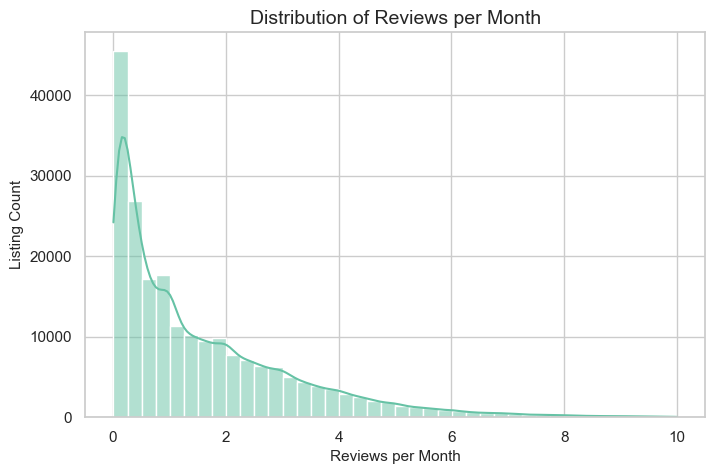

In [89]:
# plotting demand distribution with capped values so the pattern is easier to read
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df[df['reviews_per_month'] <= 10],
    x='reviews_per_month',
    bins=40,
    kde=True,
    color=set2_colors[0]
)

plt.title('Distribution of Reviews per Month')
plt.xlabel('Reviews per Month')
plt.ylabel('Listing Count')
plt.show()